<a href="https://colab.research.google.com/github/nacrocker/automated-segmentation/blob/max-tree-synthetic-signal-tests-in-colab/maxtree_tests_with_synthetic_data_and_noise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Main Code

In [1]:
# @title Machinery and Utilities - Run this cell up first opening notebook
# cell name: machinery_and_utilities
machinery_and_utilities=True

## begin synthetic_signal_machinery

import numpy as np
from scipy.signal import chirp
import matplotlib.pyplot as plt

def blackman_vs_tau(tau):
    """Blackman window vs normalized time (0 <= tau <= 1)
       This gives numpy.blackman(M) == blackman_vs_tau(taus) for taus = (numpy.arange(1-M, M, 2)/(M-1)/2) + 0.5
    """
    return 0.42 + 0.5*np.cos(2*np.pi*(tau-0.5)) + 0.08* np.cos(4*np.pi*(tau-0.5)) #0 <= tau <= 1

#def make_noise(mean, std, shape, noise_generator = np.random.normal):
def getSavedRndGenSeed():
    global SavedRndGenSeed
    if not 'SavedRndGenSeed' in globals():
        SavedRndGenSeed = np.random.SeedSequence()
    return SavedRndGenSeed


def make_noise(mean=0.0, std=1.0, shape=None, noise_generator = None, seed = None):
    if noise_generator is None: noise_generator = np.random.default_rng(seed=seed).normal
    return noise_generator(mean, std, shape)

import typing
class Chirp(typing.NamedTuple):
    amp: float = 1.0
    envlf: typing.Callable[...,typing.Any] = blackman_vs_tau
    t0: float = 0.0  #seconds
    t1: float = 1.0  #seconds
    f0: float = 1000.0 #Hz
    f1: float  = 11000.0 #Hz
    phi: float = 0.0 #degrees
    method: str = 'quadratic'
    vertex_zero: bool = True

    def __call__(self,t):
        """make chirp, c(t):
           t:  array-like float
           for t such that self.t0 <= t <= self.t1:
               c(t) = amp*envlf((t-self.t0)/(self.t1-self.t0))*
               scipy.signal.chirp(t-self.t0, self.f0, self.t1-self.t0, self.f1, method=self.method, phi=self.phi, vertex_zero=self.vertex_zero)
               where envlf is a continuous function that defines values for 0<= t <= 1.
                   the default, blackman_vs_tau, is inspired by the blackmann window where, for 0 <= t <= 1:
                   blackman_vs_tau(t) = 0.42 + 0.5*cos(2*np.pi*(t-0.5)) + 0.08*cos(4*np.pi*(t-0.5))
              self.method defaults to quadratic and self.vertex_zero defaults to true.
           for t such that t <=self.t0 or self.t1 <= t: c(t) = 0
        """
        import numpy as np
        from scipy.signal import chirp
        t = np.asarray(t).flatten()
        nt = t.size
        sig=np.zeros((nt,),dtype=float)
        it0 = np.searchsorted(t,self.t0)
        it1 = np.searchsorted(t,self.t1,side='right')-1
        ntch=it1-it0+1
        if ntch > 0:
            envl=self.envlf((t[it0:it0+ntch]-self.t0)/(self.t1-self.t0))
            sig[it0:it0+ntch] = self.amp*envl*chirp(t[it0:it0+ntch]-self.t0, self.f0, self.t1-self.t0, self.f1, method=self.method, phi=self.phi, vertex_zero=self.vertex_zero)
        return sig

def add_funcsigs(sigfunclist,t):
    sig = 0.0
    for sgf in sigfunclist: sig+=sgf(t)
    return sig

## end synthetic signal machinery

## begin max_tree_machinery

class Cached_Computed_Attributes:
    '''mixin class with methods for managing cached computed attributes'''

    @staticmethod
    def cached_computed_attribute(attribute_name):
        def cached_computer_attribute_decorator(attribute_compute_method):

            def attribute_compute_method_with_caching(self):
                if self.is_cached(attribute_name):
                    ret = self.get_cached(attribute_name)
                    if not (ret is None): return ret

                attribute = attribute_compute_method(self)

                self.cache(attribute_name,attribute)
                return attribute

            return property(attribute_compute_method_with_caching)
        return cached_computer_attribute_decorator


    _listy_types = (list, tuple)
    def cache(self,attr,val):
        """Cache a computed attribute"""
        if (attr,str):
            setattr(self,'_'+attr,val)
            self._cached[attr]=attr
            return None

    @property
    def cached(self):
        """Get dictionary of cached computed attributes."""
        return {k:getattr(self,'_'+k) for k in self._cached.keys()}

    def list_cached(self):
        """Get names of cached computed attributes."""
        return self._cached.keys()

    def is_cached(self,attr):
        """Test if attribute or list of attribures is cached"""
        if isinstance(attr,self.__class__._listy_types):
            return [self.is_cached(a) for a in attr]

        if isinstance(attr,str):
            return attr in self._cached and hasattr(self,'_'+attr)

        #if this point is reached, something is wr

    def add_alias_to_cached(self,attr,alias):
        """Add alias or list of alias to attributes"""

        if isinstance(attr,self.__class__._listy_types) and isinstance(alias,self.__class__._listy_types) and len(attr) == len(alias):
            for a,al in zip(attr,alias): self.add_alias_to_cached(a,al)
            return None

        if isinstance(attr,str):
            if self.is_cached(attr) is None: raise KeyError(attr)
            self._cached[alias] = attr
            return None

        #if this point is reached, something is wrong.
        raise ValueError('attr should be attribute name or list of attribute names.')


    def is_alias_to_cached(self,attr):
        """Test if atrributes are aliass to other attributes."""
        if isinstance(attr,_listy_types):
            return [self.is_alias_to_cached(a) for a in attr]

        if isinstance(attr,str):
            if self.is_cached(attr) is None: raise KeyError(attr)
            return attr == self._cached[attr]

        #if this point is reached, something is wrong.
        raise ValueError('attr should be attribute be name or list of attribute names.')


    def dereference_alias(self,attr):
        """Dereference aliases to cached computed attributes. Non-aliases will deference to themselves."""
        if isinstance(attr,self.__class__._listy_types):
            return [self.dereference_alias(a) for a in attr]

        if isinstance(attr,str):
            if self.is_cached(attr) is None: raise KeyError(attr)
            return self._cached[attr]

        #if this point is reached, something is wrong.
        raise ValueError('attr should attribute name or list of attribute names.')


    def get_cached(self,attr):
        """Get cached computed attribute values"""
        if isinstance(attr,self.__class__._listy_types):
            return [self.get_cached(a) for a in attr]

        if isinstance(attr,str):
            if self.is_cached(attr) is None: raise KeyError(attr)
            return getattr(self,'_'+attr)

        #if this point is reached, something is wrong.
        raise ValueError('attr should be attribute name or list of attribute names.')


    def clear_cached(self,attr=None,all=False):
        """Clear cached computed attributes by name or list of names, or all by all=True."""
        def _safe_clear_cached(attr):
            if hasattr(self,'_'+attr): delattr(self,'_'+attr)
            if attr in self._cached: self._cached.pop(attr)

        if attr is None: return None

        if all:
            for a in attr: self.clear_cached(a)
            return None

        if isinstance(attr,self.__class__._listy_types):
            for a in attr: self.clear_cached(a)
            return None

        if isinstance(attr,str):
            if self.is_cached(attr) is None: raise KeyError(attr)
            _safe_clear_cached(attrs)
            return None

        #if this point is reached, something is wrong.
        raise ValueError('attr should be attribute name or list of attribute names, or all=True should be provided.')


class Max_Tree(Cached_Computed_Attributes):
    import numpy as np

    def __init__(self,image=None,connectivity=1):
        self._cached={}
        self._connectivity = connectivity
        if image is None:
            self._image=None
            self._connectivity=None
            self._P=None
            self._S=None
            return
        from skimage.morphology import max_tree as max_tree_ski
        self._image = image
        self._P,self._S = max_tree_ski(image, connectivity=self._connectivity)


    @property
    def image(self):
        """Get the max_tree image"""
        return self._image

    @property
    def P(self):
        """Get the max_tree parent matrix"""
        return self._P

    @property
    def S(self):
        """Get the max_tree traverser array"""
        return self._S

    @property
    def parent(self):
        """Get max_tree parent matrix"""
        return self.P

    @property
    def sorted_indices(self):
        """Get max_tree sorted_indices array"""
        return self.S

    @property
    def connectivity(self):
        """Get the max_tree connectivity."""
        return self._connectivity


    cached_computed_attribute=Cached_Computed_Attributes.cached_computed_attribute

    @cached_computed_attribute('C')
    def C(self):
        S = self.S
        P_rav = self.P.ravel()
        C_rav = [[] for _ in range(len(P_rav))]
        C = np.empty(self.image.shape,dtype=list)
        for p in S[1:]:
            q = P_rav[p]
            C_rav[q].append(p)
        C.ravel()[:]= C_rav[:]
        return C

    @cached_computed_attribute('children')
    def children(self):
        return self.C

    @cached_computed_attribute('canonicality')
    def canonicality(self):
        """Get the canonicality of each position in P, the parent matrix. i.e. whether it represents a component"""
        if self._image is None: return None

        image = self._image
        image_rav = image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S

        canonicality_rav = image_rav != image_rav[parent]
        p_root = sorted_indices[0]
        canonicality_rav[p_root] = True
        canonicality = np.reshape(canonicality_rav,self.P.shape)

        return canonicality



    @cached_computed_attribute('numcomponents')
    def numcomponents(self):
        """Get the number of components."""
        if self._image is None: return None

        numcomponents = np.sum(self.canonicality)
        return numcomponents



    @cached_computed_attribute('sorted_labels')
    def sorted_labels(self):
        """Get the component labels for each of the node in S, the sorted_indices array.
        Non-canonical nodes have a value equal to the negative of their canonical parent label.
        Label magnitudes increase from 0 starting at beginning of sorted_labels. """
        if self._image is None: return None

        sorted_labels=np.cumsum(self.canonicality[self.S])
        sorted_labels[~self.canonicality[self.S]] *= -1
        return sorted_labels


    @cached_computed_attribute('labels')
    def labels(self):
        """Get the component labels for each of the node in P, the parent matrix.
        Non-canonical nodes have a value equal to the negative of their canonical parent label."""
        if self._image is None: return None

        labels = self._P.copy()
        labels.ravel()[self.S] = self.sorted_labels

    @cached_computed_attribute('component_P_indices')
    def component_P_indices(self):
        """Get the indices (aka P-indices) in P, or the parent matrix, for the node correposonding to component to which the node belongs.
        For a canonical node, component_P_indices.ravel()[i] == i."""
        if self._image is None: return None

        image = self._image
        image_rav = image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S

        indices=np.reshape(np.arange(parent.size),self.P.shape)
        indices_rav=indices.ravel()

        for p in sorted_indices[:0:-1]:
            q = parent[p]
            if image_rav[q] == image_rav[p]: indices_rav[p]=indices_rav[q]

        return indices


    @cached_computed_attribute('order')
    def order(self):
        """Get the position within S, the sorted_indices array, of nodes in P, the parent matrix.
        In other words, for a node i in P.ravel(), S[order[i]] == i"""
        if self._image is None: return None

        image = self._image
        image_rav = image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S

        order = np.argsort(self.sorted_indices)

        return order


    @cached_computed_attribute('order_P_indices')
    def order_P_indices(self):
        """Get the order within S, the sorted_indices array, of the P-indices (component indices in P).
        For a canonical node i in P.ravel(), S[order_P_indices[i]] == i.
        For a non-canoncical node i in P.ravel(), S[order_P_indices[i]] == P.ravel[i]"""
        if self._image is None: return None

        image = self._image
        image_rav = image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S

        order = self.order

        for p in sorted_indices[:0:-1]:
            q = parent[p]
            if image_rav[q] == image_rav[p]:
                order[p] = order[q]

        return order


    @cached_computed_attribute('numchildren')
    def numchildcomponents(self):
        """Get the number of child components for each comoenent node.
        Non-canonical nodes will have values which are the negative of the number of components for their parent component node."""
        if self._image is None: return None

        image = self._image
        image_rav = image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S

        numchildren = np.zeros(image.shape, dtype=int)
        numchildren_rav=numchildren.ravel()

        for p in sorted_indices[:0:-1]:
            q = parent[p]
            if image_rav[q] != image_rav[p]:
                numchildren_rav[q] += 1

        for p in sorted_indices[:0:-1]:
            q = parent[p]
            if image_rav[q] == image_rav[p]:
                numchildren_rav[p] = -numchildren_rav[q]

        return numchildren

    @cached_computed_attribute('numchildnodes')
    def numchildnodes(self):
        """Get the number of children in the max-tree for each tree node (count includes non-canonical nodes)."""
        if self._image is None: return None

        image = self._image
        image_rav = image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S

        numchildren = np.zeros(image.shape, dtype=int)
        numchildren_rav=numchildren.ravel()

        for p in sorted_indices[:0:-1]:
            q = parent[p]
            numchildren_rav[q] += 1

        return numchildren

    @cached_computed_attribute('leaf_P_indices')
    def leaf_P_indices(self):
        """Get the P-indices of component leaf nodes. (Note that non-canonical nodes are leaf nodes but not component leave nodes.)"""
        if self._image is None: return None

        return np.flatnonzero(self.numchildnodes == 0)

    @property
    def leaves(self):
        """Alias for leaf_P_indices"""
        return self.leaf_P_indices

    @cached_computed_attribute('sorted_leaf_P_indices')
    def sorted_leaf_P_indices(self):
        """Get the P-indices ??? of component leaf nodes. (Note that non-canonical nodes are leaf nodes but not component leave nodes.)"""
        if self._image is None: return None

        return self.S[np.flatnonzero(self.numchildnodes.ravel()[self.S] == 0)]

    @cached_computed_attribute('peak')
    def peak(self):
        """Get the peak (max intensity) for each component."""
        if self._image is None: return None

        image = self._image
        parent = self._P.ravel()
        sorted_indices = self._S

        peak = image.copy()

        image_rav = image.ravel()
        peak_rav = peak.ravel()

        for p in sorted_indices[:0:-1]:
            q = parent[p]
            if image_rav[p] != image_rav[q]:
                peak_rav[q] = max(peak_rav[p], peak_rav[q])  # search maximum and propagate maximum to parent node
            else:
                # canonicalize value. this works because the sort_indices order will cause all
                # canonical children of q to be reached before non-canonical children
                peak_rav[p] = peak_rav[q]
        return peak


    @property
    def contrast(self):
        """Get the contrast for each component. contrast=max_over_component(intensity)/min_over_component(intensity)"""
        if self._image is None: return None

        contrast = ((self.peak).copy()).astype(np.float64)/self._image

        return contrast


    @property
    def log_contrast(self):
        """Get the log of contrast for each component. logContrast = log(max_over_component(intensity)) - log(min_over_component(intensity))."""
        if self._image is None: return None

        log_contrast = np.log(((self.peak).copy()).astype(np.float64))-np.log(self._image)

        return log_contrast


    @cached_computed_attribute('height')
    def height(self):
        """Get the height for each component.  Height = max_over_component(intensity)-min_over_component(intensity)"""
        if self._image is None: return None

        height = ((self.peak).copy()).astype(np.float64)-self._image

        return height

    @cached_computed_attribute('area')
    def area(self):
        """Get the area (number of pixels) for each component."""
        if self._image is None: return None

        image = self._image
        image_rav = image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S

        area = np.ones(image.shape, dtype=int)
        area_rav=area.ravel()

        for p in sorted_indices[:0:-1]:
            q = parent[p]
            area_rav[q] += area_rav[p]

        for p in sorted_indices[1:]:
            q = parent[p]
            if image_rav[p] == image_rav[q]:
                area_rav[p] = area_rav[q] # canonicalize value

        return area



    @cached_computed_attribute('volume')
    def volume(self):
        """Get the volume for each component. Volume = sum_over_component(intensity-min_over_parent_component(intensity))"""
        if self._image is None: return None

        image = self._image
        image_rav = image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S
        area = self.area
        area_rav=area.ravel()

        volume = np.zeros(image.shape, dtype=np.float64)
        volume_rav=volume.ravel()

        for p in sorted_indices[:0:-1]:
            q = parent[p]
            if image_rav[p] != image_rav[q]:
                volume_rav[q] += area_rav[p]*(image_rav[p]-image_rav[q])+volume_rav[p]

        for p in sorted_indices[1:]:
            q = parent[p]
            if image_rav[p] == image_rav[q]:
                volume_rav[p] = volume_rav[q] # canonicalize value

        return volume


    @cached_computed_attribute('extents')
    def extents(self):
        """Get the extent (index ranges for each coordinate) for each component."""
        if self._image is None: return None

        image = self._image
        image_rav=image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S

        number_of_pixels = np.size(image)

        max_coord = np.array(np.unravel_index(np.arange(number_of_pixels), image.shape)).T
        min_coord = np.array(np.unravel_index(np.arange(number_of_pixels), image.shape)).T
        extents = np.ones((*image.shape,2),dtype=int)
        extents_rav = extents.reshape((number_of_pixels,2))

        for p in sorted_indices[:0:-1]:
            q = parent[p]
            max_coord[q] = np.maximum(max_coord[q], max_coord[p])
            min_coord[q] = np.minimum(min_coord[q], min_coord[p])
            extents_rav[q] = (max_coord[q] - min_coord[q]) + 1

        for p in sorted_indices[1:]:
            q = parent[p]
            if image_rav[p] == image_rav[q]:
                extents_rav[p] = extents_rav[q] # canonicalize value

        return extents

    @property
    def extension(self):
        """Get the maximum of all extents (index ranges for each coordinate) for each component."""
        if self._image is None: return None

        return np.max(self.extents,axis=2)

    @property
    def diameter(self):
        """Get diameter (alias for extension) for each component."""
        return self.extension


    def fill_components_from_markers(self,markers=None,unmarked=0,preserve_nesting=False):

        image = self._image
        if markers is None or not np.array_equal(markers.shape,image.shape):
            raise ValueError('markers should be matrix with same shape as image')

        image=self.image
        image_rav=image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S
        output = markers.copy()
        output_rav=output.ravel()

        if np.isnan(unmarked):
            for p in sorted_indices[:0:-1]:
                #if noncanonical node is marked, mark canonical parent
                q = parent[p]
                if image_rav[q] == imag_rav[p] and ~np.isnan(output_rav[p]): output_rav[q] = output_rav[p]

            for p in sorted_indices[1:]:
                q = parent[p]
                if ~np.isnan(output_rav[q]) and (not preserve_nesting or np.isnan(output_rav[p])) : output_rav[p] = output_rav[q]
        else:
            for p in sorted_indices[:0:-1]:
                #if noncanonical node is marked, mark canonical parent
                q = parent[p]
                if image_rav[q] == image_rav[p] and output_rav[p] != unmarked: output_rav[q] = output_rav[p]

            for p in sorted_indices[1:]:
                # is parent is marked, mark child.
                q = parent[p]
                if output_rav[q] != unmarked and (not preserve_nesting or output_rav[p] == unmarked): output_rav[p] = output_rav[q]

        return output


    def direct_filter(self,attribute='area',attribute_threshold=3):
        """Apply a direct filtering.

        This produces an image in which for all possible thresholds, each connected
        component has the specified attribute value greater than that threshold.
        This is the basic function called by :func:`area_opening`,
        :func:`diameter_opening`, and similar.

        For :func:`area_opening`, for instance, the attribute is the area.  In this
        case, an image is produced for which all connected components for all
        thresholads have at least an area (pixel count) of the threshold given by
        the user.

        Parameters
        ----------

        attribute : name of attribute or array of float with same shape as image
            that ontains the attributes computed for the max-tree.
        attribute_threshold : float
            The threshold to be applied to the attribute.

        Notes
        ----------
        Adapted from source code for skimage max_tree:
        https://github.com/scikit-image/scikit-image/blob/v0.25.2/skimage/morphology/_max_tree.pyx
        """

        image = self._image

        isvalidattr = False
        if isinstance(attribute,str) and hasattr(self,attribute):
                attrtemp=getattr(self,attribute)
                if np.array_equal(attrtemp.shape,image.shape):
                    attribute=attrtemp
                    isvalidattr = True
        else:
            if np.array_equal(attribute.shape,image.shape): isvalidattr = True

        if not isvalidattr:  raise ValueError('attr should be attribute name or array with same shape as image')


        image_rav=image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S
        attribute_rav=attribute.ravel()

        output = image.copy()
        output_rav=output.reshape((size(image),*output.shape[2:]))

        p_root = sorted_indices[0]
        if attribute_rav[p_root] < attribute_threshold:
            output_rav[p_root] = 0
        else:
            output_rav[p_root] = image_rav[p_root]

        for p in sorted_indices[1:]:
            q = parent[p]

            # this means p is not canonical
            # in other words, it has a parent that has the
            # same image value.
            if image_rav[p] == image_rav[q]:
                output_rav[p] = output_rav[q]
                continue

            if attribute_rav[p] < attribute_threshold:
                # this corresponds to stopping
                # as the level of the lower parent
                # is propagated to the current level
                output_rav[p] = output_rav[q]
            else:
                # here the image reconstruction continues.
                # The level is maintained (original value).
                output_rav[p] = image_rav[p]

        return output

    def maxattrclosing(self,attr,return_nodes=False):
        """propagates maxiumum attr value along lineage from root back to leaf. For non-monotonic attributes, this fills any valley between highest value descendenent and leaf"""
        image_rav = self.image.ravel()
        S=self.S
        parent=self.P.ravel()
        maxattr = attr.copy()
        maxattr_rav=maxattr.ravel()
        if return_nodes:
            maxattrnodes = np.zeros(attr.shape,dtype=bool)
            maxattrnodes_rav = maxattrnodes.ravel()
            maxattrnodes_rav[S[0]] = True
            for p in S[1:]:
                q=parent[p]
                if image_rav[p] != image_rav[q]:
                    if maxattr_rav[p] >= maxattr_rav[q]:
                        #maxattr_rav[p] = maxattr_rav[p]
                        maxattrnodes_rav[p] = True
                        maxattrnodes_rav[q] = False
                    else:
                        maxattr_rav[p] = maxattr_rav[q]
                else:
                    maxattr_rav[p] = maxattr_rav[q] #canoicalize maxattr
            return (maxattr,maxattrnodes)
        else:
            for p in S[1:]:
                q=parent[p]
                if image_rav[p] != image_rav[q]:
                    maxattr_rav[p] = np.maximum(maxattr_rav[p],maxattr_rav[q])
                else:
                    maxattr_rav[p] = maxattr_rav[q] #canoicalize maxattr
            return maxattr

    def leafattrflatnodes(self,attr,attrthresh=None,mask=None):
        """marks nodes for components with flat attribute value around leaves (e.g. from area opening) """
        image_rav=self.image.ravel()
        S=self.S
        parent=self.P.ravel()
        flatnodes = self.numchildnodes == 0 # will only mark true leaves, not non-canonical nodes.
        if not attrthresh is None: flatnodes = flatnodes & (attr >= attrthresh)
        if not mask is None: flatnodes = flatnodes & mask
        flatnodes_rav = flatnodes.ravel()
        attr_rav=attr.ravel()
        for p in S[:0:-1]:
            q=parent[p]
            if flatnodes_rav[p] and attr_rav[q] == attr_rav[p]:
                #move flatzone node marker to parent of flatzone
                flatnodes_rav[q] = True
                flatnodes_rav[p] = False
        return flatnodes

    def leafattrflatzones(self,attr,attrthresh=None,mask=None):
        """marks zones of flat attribute value around leaves (e.g. from area opening) """
        image_rav=self.image.ravel()
        S=self.S
        parent=self.P.ravel()
        flatzones=self.numchildnodes == 0  # mark leaves
        if not attrthresh is None: flatzones = flatzones & (attr >= attrthresh)  #mark leaves with attr above threshold
        if not mask is None: flatzones = flatzones & mask  # filter markers with mask
        flatzones_rav=flatzones.ravel()
        attr_rav=attr.ravel()
        for p in S[:0:-1]:
            q=parent[p]
            if flatzones_rav[p] and attr_rav[q] == attr_rav[p]: # non-canonical node should never satify flatzones_rav[p] == True here
                flatzones_rav[q] = True # propate marker to parent with same value of attr (i.e. parent in flatzone of child)
            #if flatzones_rav[q] and image_rav[p] == image_rav[q]:
            ## noncanonical node takes on flatzone membership if canonical parent it is in flatzone.
            ## parent should already have membership established because of order of S
            #    flatzones_rav[p] = True
        for p in S[1:]:
            q = parent[p]
            if image_rav[p] == image_rav[q]:
                flatzones_rav[p] = flatzones_rav[q] # canonicalize value


        return flatzones

    def path_to_root_as_P_indices(self,P_index):
        """Get path from node to root as P-indices"""
        if self._image is None: return None
        P_rav=self.P.ravel()
        def pathfrom(q):
            p = None
            while q != p:
                yield q
                p = q
                q = P_rav[p]

        return np.fromiter(pathfrom(P_index),int)

    def isdescendent(self,node=None,of=None):
        "Tests if node is descendent of another node. If nodes are non-canonical, their canonical parents are tested."
        if self._image is None: return None

        numP=self.P.size
        if not np.issubdtype(type(node),np.integer) or not node in range(numP):
             raise ValueError(f'"node" argument should be P-index , an integer in range({numP}).')
        if not np.issubdtype(type(of),np.integer) or not of in range(numP):
             raise ValueError(f'"of" argument should be P-index label, an integer in range({numP}).')


        P_rav=self.P.ravel()
        image_rav=self.image.ravel()
        S = self.S

        qof = P_rav[of]
        if of != S[0] and image_rav[of] == image_rav[qof]: of = qof

        if of == S[0]: return node != S[0]

        qnode = P_rav[node]
        if node != S[0] and image_rav[node] == image_rav[qnode]: node = qnode


        order = self.order.ravel()

        oforder=order[of]
        ancestor = node
        oldancestor = None
        while order[ancestor] >= oforder:
            oldancestor = ancestor
            ancestor = P_rav[oldancestor]

        return order[ancestor] == oforder


    def markancestors(self,nodes):
        image_rav=self.image.ravel()
        P_rav=self.P.ravel()
        ancestors=np.zeros(self.image.shape,dtype=bool)
        ancestors_rav=ancestors.ravel()

        for n in nodes:
            qn = P_rav[n]
            if image_rav[qn] == image_rav[n]: qn = P_rav[qn]
            while not ancestors_rav[qn] and qn != n:
                ancestors_rav[qn] = True
                n = qn
                qn = P_rav[n]
        return ancestors


    def maxattrnodes(self,attr,allchildren=True):
        """Find nodes which are local maxima of attr value along lineage. A maximum passes two tests:
        (1) attr.ravel()[parent] < attr.ravel()[node]
        (2) if allchildren:
              attr.ravel()[node] >= attr.ravel[child] for all children.
            else:
              attr.ravel()[node] >= attr.ravel[child] for any child.
        """
        S=self.S
        P_rav=self.P.ravel()
        image_rav=self.image.ravel()
        attr = attr.copy()

        attr_rav=attr.ravel()
        isnoncanonical = image_rav == image_rav[P_rav]
        attr_rav[isnoncanonical] = attr_rav[P_rav[isnoncanonical]] # canonicalize attr

        maxattrnodes=np.zeros(self.image.shape,dtype=bool)
        maxattrnodes_rav = maxattrnodes.ravel()

        ##Vectorized, faster code than for-loops below:
        maxattrnodes_rav[:] = (attr_rav[P_rav] <= attr_rav) & ~isnoncanonical
        if allchildren:
            np.logical_and.at(maxattrnodes_rav,P_rav,attr_rav[P_rav]>attr_rav)
        else:
            np.logical_or.at(maxattrnodes_rav,P_rav,attr_rav[P_rav]>attr_rav)

        return maxattrnodes

        ##Equivalent to, but slower than, vecotrized code above:
        #for p in S[1:]:
        #    q = P_rav[p]
        #    maxattrnodes_rav[p] = attr_rav[q] < attr_rav[p]
        #
        #if allchildren:
        #    for p in S[1:]:
        #        q = P_rav[p]
        #        maxattrnodes_rav[q] = maxattrnodes_rav[q] and attr_rav[q] >= attr_rav[p]
        #else:
        #    for p in S[1:]:
        #        q = P_rav[p]
        #        maxattrnodes_rav[q] = maxattrnodes_rav[q] or attr_rav[q] >= attr_rav[p]
        #return maxattrnodes



    def priorityprunenodes(self,nodeinds):
        """Given a list of nodes (by P-index) in order of increasing priorty, nodes with higher priority ancestors or decendents will be pruned."""
        from collections import deque

        image_rav=self.image.ravel()
        P_rav=self.P.ravel()
        nodes = np.zeros(self.P.shape,dtype=bool)
        nodes_rav = nodes.ravel()
        nodes_rav[nodeinds] = True
        children = self.children
        children_rav=children.ravel()
        occluded_rav=np.zeros(P_rav.shape,dtype=bool)

        for p in nodeinds[::-1]:
            q = P_rav[p]
            if image_rav[q] == image_rav[p]: # only deal with canonical nodes. no effect if node is actually root.
                p,q = q,P_rav[p]
            if occluded_rav[p]: continue # this maximum was eliminated in previous iteration
            pmax = p
            while not occluded_rav[q] and q != p:
                occluded_rav[q] = True
                p = q
                q = P_rav[p]

            #childqueue=children_rav[p][:]
            childqueue=deque(children_rav[pmax])
            while childqueue:
                c = childqueue.popleft()
                occluded_rav[c] = True
                childqueue.extend(children_rav[c])

        nodes_rav[:]&=~occluded_rav

        return np.flatnonzero(nodes_rav)

    def optimummaxattrnodes(self,attr,maxattrnodes=None):
        """Given a boolean matrix (maxattrnodes) where nodes with maximum attribute value are True, eliminate suboptimum maxima,
        which have any of these properties:
        1) a descendent maximum with higher or equal value
        2) an ancestor maximum with higher value that has no descendent maximum with even higher value
        If maxattrnodes argument is None, then calculate it."""

        from collections import deque

        image_rav=self.image.ravel()
        P_rav=self.P.ravel()
        if maxattrnodes is None:
            maxattrnodes = self.maxattrnodes(attr)
        else:
            maxattrnodes = maxattrnodes.copy()
        attr_rav=attr.ravel()
        maxattrnodes_rav = maxattrnodes.ravel()
        maxattrndinds = np.flatnonzero(maxattrnodes_rav)
        maxattrndinds = maxattrndinds[np.argsort(attr_rav[maxattrndinds])]
        children = self.children
        children_rav=children.ravel()
        occluded_rav=np.zeros(P_rav.shape,dtype=bool)

        for p in maxattrndinds[::-1]:
            q = P_rav[p]
            if image_rav[q] == image_rav[p]: # only deal with canonical nodes. no effect if node is actually root.
                p,q = q,P_rav[p]
            if occluded_rav[p]: continue # this maximum was eliminated in previous iteration
            pmax = p
            while not occluded_rav[q] and q != p:
                occluded_rav[q] = True
                p = q
                q = P_rav[p]

            #childqueue=children_rav[p][:]
            childqueue=deque(children_rav[pmax])
            while childqueue:
                c = childqueue.popleft()
                occluded_rav[c] = True
                childqueue.extend(children_rav[c])

        maxattrnodes_rav[:]&=~occluded_rav

        return maxattrnodes


    def accumulate_attribute_from_leaf_to_root(self,attr):
        """get the accumulated value of attr when walking tree from leaft to root. gives area if attr == np.ones(self.image.shape)"""
        image = self.image
        image_rav=image.ravel()
        P_rav = self.P.ravel()
        S = self.S
        acc=attr.copy()
        acc_rav = acc.reshape((np.size(image),*acc.shape[2:]))

        for p in S[:0:-1]:
            q = P_rav[p]
            acc_rav[q]+=acc_rav[p]

        for p in S[1:]:
            q = P_rav[p]
            if image_rav[p] == image_rav[q]:
                acc_rav[p] = acc_rav[q] # canonicalize value

        return acc

    def label_image_components(self,nodeinds,labels,returnLabledNodes=False):
        labled_nodes = np.zeros(self.image.shape)
        np.put(labled_nodes,nodeinds,labels)
        labled = self.fill_components_from_markers(labled_nodes)
        if returnLabledNodes:
            return labled,labled_nodes
        else:
            return labled

    def label_optimummaxattrnode_image_components_with_rank_and_attr(self,attr):
        mxatnds = self.maxattrnodes(attr) # Find nodes which are local maxima of attr value along lineage.
        mxatnds = self.optimummaxattrnodes(attr,maxattrnodes=mxatnds) #prune attr-maximum nodes to leave only nodes with no descencdent having higher attr value. has shape of attr, with nonzero values for only surviving nodes
        mxatndinds = np.flatnonzero(mxatnds) # nonzero nodes mxatnds are the winners of the pruning. get their indices.
        mxatndinds = mxatndinds[np.argsort(attr.ravel()[mxatndinds])] # sort the indices in order for increasing attr value.
        mxatndsranktopfill, mxatndsranktop = self.label_image_components(mxatndinds,range(mxatndinds.size,0,-1),returnLabledNodes=True) #for each winning node, assiat integer rank label to node in matrix, with 1 as highest rank and higher integer for lower rank.  Fill components corresponding to nodes and return filled matrix along with matrix of ranked nodes.
        mxattop=attr*(mxatndsranktop > 0) # replace rank in ranked node matrix with attr value for node
        mxattopfill = self.fill_components_from_markers(mxattop) # fill components corresponding to nodes with their attr values.
        return mxatndsranktopfill,mxattopfill

    def gain_predefined(self,choice):
        predefined_gains = {
            'avspecdens': lambda: self.volume/self.area*self.extents[...,1],
            'avspecheight': lambda: self.volume/self.area,
            #the following don't work well at all
            #'signaltonoise': lambda: self.volume/(self.area*self.image),
            #'specdens_signaltonoise': lambda:self.volume*self.extents[...,1]/(self.area*self.image),
            #'volume_growth': lambda:self.volume*self.extents[...,1],
        }
        assert choice in predefined_gains, f'choice must be one of {list(predefined_gains.keys())}'
        return predefined_gains[choice]()

max_tree = Max_Tree
## end max_tree_machinery


## begin plot_utils
def cmapIDL_Standard_Gamma_II():
    # Colormap definition for "Standard Gamma-II" colormap from IDL
    import matplotlib
    from matplotlib import cm
    import numpy as np

    _r = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   4, 9, 14, 19, 23, 28, 33, 38, 42, 47, 52, 57, 61, 66, 71, 76,
                   81, 81, 81, 81, 81, 81, 81, 81, 80, 80, 80, 80, 80, 80, 80, 79,
                   84, 89, 94, 99, 104, 109, 114, 119, 124, 129, 134, 139, 144, 149, 154, 159,
                   164, 169, 174, 180, 185, 190, 196, 201, 206, 212, 217, 222, 228, 233, 255, 255,
                   255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
                   255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
                   255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
                   255, 255, 255, 248, 240, 232, 225, 217, 209, 202, 194, 186, 179, 171, 163, 168,
                   173, 178, 183, 188, 193, 198, 203, 209, 214, 219, 224, 229, 234, 239, 244, 249,
                   255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
                   255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
                   255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
                   255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255])
    _g = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 5, 10, 16, 21, 27, 32, 37, 43, 48, 54, 59, 64, 70, 75,
                   81, 85, 90, 95, 100, 105, 109, 114, 119, 124, 129, 134, 138, 143, 148, 153,
                   158, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163,
                   163, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163,
                   163, 169, 175, 181, 187, 193, 199, 205, 212, 218, 224, 230, 236, 242, 248, 255,
                   255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
                   255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
                   255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
                   255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255])
    _b = np.array([0, 5, 10, 15, 20, 26, 31, 36, 41, 46, 52, 57, 62, 67, 72, 78,
                   83, 88, 93, 98, 104, 109, 114, 119, 124, 130, 135, 140, 145, 150, 156, 161,
                   166, 171, 176, 182, 187, 192, 197, 202, 208, 213, 218, 223, 228, 234, 239, 244,
                   249, 255, 250, 245, 239, 234, 228, 223, 218, 212, 207, 201, 196, 190, 185, 180,
                   174, 169, 163, 158, 152, 147, 142, 136, 131, 125, 120, 114, 109, 104, 98, 93,
                   87, 82, 76, 71, 66, 60, 55, 49, 44, 38, 33, 28, 22, 17, 11, 6,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 4, 9, 14, 19, 24, 28, 33, 38, 43, 48, 53, 57, 62, 67, 72,
                   77, 82, 77, 71, 65, 59, 53, 47, 41, 36, 30, 24, 18, 12, 6, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 3, 6, 9, 12, 16, 19, 22, 25, 29, 32, 35, 38, 41, 45, 48,
                   51, 54, 58, 61, 64, 67, 71, 74, 77, 80, 83, 87, 90, 93, 96, 100,
                   103, 106, 109, 112, 116, 119, 122, 125, 129, 132, 135, 138, 142, 145, 148, 151,
                   154, 158, 161, 164, 167, 171, 174, 177, 180, 183, 187, 190, 193, 196, 200, 203,
                   206, 209, 213, 216, 219, 222, 225, 229, 232, 235, 238, 242, 245, 248, 251, 255])
    _rgb = np.column_stack((_r, _g, _b)) / 255.0
    cmstd=matplotlib.colors.ListedColormap(_rgb, name='Standard_Gamma_II')
    #cm.register_cmap(name='Standard_Gamma_II',cmap=cmstd)
    setattr(cm,'Standard_Gamma_II',cmstd)

    if not hasattr(cmstd,'_reversed_orig'):
        cmstd._reversed_orig = cmstd.reversed
    def cmstd_reversed(self,name=None):
        if name is None:
            name='Standard_Gamma_II_r'
        cmstd_rvsrd = cmstd._reversed_orig(name=name)
        setattr(cm,name,cmstd_rvsrd)
        return cmstd_rvsrd
    cmstd.reversed = cmstd_reversed.__get__(cmstd)

    return cmstd
#    return matplotlib.colors.ListedColormap(_rgb, name='hot')# name='Standard Gamma-II')

def imshowxy(x,y,img,xlabel=None,ylabel=None,title=None,ax=plt,cbkwargs=None,**kwargs):
    import matplotlib.pyplot as plt
    import numpy as np
    #fig, ax = plt.subplots()
    #extent=(np.min(x.ravel()),np.max(x.ravel()),np.min(y.ravel()),np.max(y.ravel()))
    #bnds=lambda coord: polyval(polyfit([0,len(coord)-1],[m(coord) for m in [np.min,np.max]],1),[-0.5,len(coord)-0.5])
    bnds = lambda coord: (lambda dcoord: [-dcoord/2+coord[0],+dcoord/2+coord[-1]])((coord[-1]-coord[0])/(len(coord)-1))
    extent=(*bnds(x),*bnds(y))
    im=ax.imshow(img,aspect='auto',origin='lower',extent=extent,**kwargs)
    if xlabel: plt.ylabel(ylabel)
    if ylabel: plt.xlabel(xlabel)
    if title: plt.title(title)
    if cbkwargs is None: cbkwargs = dict()
    cb=plt.colorbar(**cbkwargs)
    return im,cb

def specim(time,freq,spec,ax=plt,interpolation='none',cbkwargs=None,**kwargs):
    import matplotlib.pyplot as plt
    import numpy as np
    #im=ax.imshow(spec,aspect='auto',origin='lower',extent=(time[0],time[-1],freq[0],freq[-1]),**kwargs)
    #plt.ylabel('freq')
    #plt.xlabel('time')
    #cb=plt.colorbar()
    kwargs.setdefault('xlabel','time')
    kwargs.setdefault('ylabel','freq')
    im,cb=imshowxy(time,freq,spec,ax=ax,interpolation=interpolation,cbkwargs=cbkwargs,**kwargs)
    return im,cb

## end plot_utils

## begin math_utils

def assigntoarr(arr,ind,vals):
    import numpy as np
    np.put(arr,ind,vals)
    return arr

def boolindices(shape,ind,raveled_indices=False):
    import numpy as np
    bi = np.zeros(shape,dtype=bool)
    if raveled_indices:
        bi.ravel()[ind] = True
    else:
        bi[ind]=True

    return bi

def zerotonan(arr):
    return np.where(arr == 0,np.nan,arr)

def ravel_vec(vecarr):
    return vecarr.reshape((np.prod(vecarr.shape[0:-1]),vecarr.shape[-1]))

## end math_utils

## begin spectrogram_machinery
from scipy.signal import ShortTimeFFT
def stft_sig(sig,win_param='hann',fs=1.0,nperseg=None,overlap=0.0,returnSFT=False):
    nt=len(sig)
    if nperseg is None: nperseg=(int(np.ceil(np.sqrt(nt))) // 2) * 2
    nfft = nperseg
    noverlap=int(nfft*overlap)
    SFT = ShortTimeFFT.from_window(win_param='hann', fs=fs, nperseg=nfft,noverlap=noverlap)
    sigstft = SFT.stft(sig)
    fsigstft = SFT.f
    tsigstft = SFT.t(sig.size)
    if returnSFT:
        return sigstft,fsigstft,tsigstft,SFT
    else:
        return sigstft,fsigstft,tsigstft
## end spectrogram_machinery

## local convenience utilities
def show_top_components_rank_and_gain(sp,rankLabledComponents,valueLabeledComponents,ntop=10,panelsize=(3,4)):
    #rankLabledComponents: matrix of sames size as sp, with labeled components. labels are integers with 0=background and lower label means higher rank.
    #gainLabledComponents: matrix of sames size as sp, with labeled components. labels are value, which is real, with 0=background.
    topComponentsFilt = ((rankLabledComponents > 0) & (rankLabledComponents <= ntop))

    def zerotonan(arr):
        return np.where(arr == 0,np.nan,arr)

    rsz,csz = panelsize
    nr,nc = 1,3

    cmap='viridis'

    from matplotlib.gridspec import GridSpec
    from matplotlib.colors import LogNorm
    import matplotlib
    CSS4 = matplotlib.colors.CSS4_COLORS

    #bgcolor = CSS4['aliceblue']
    #bgcolor = CSS4['lightcyan']
    bgcolor = CSS4['lightgray']

    fig = plt.figure(figsize=(nc*csz,nr*rsz),layout='constrained')
    gs = GridSpec(nr,nc, figure=fig)

    kwextra={}
    vlimdict={}

    handles=[fig]

    gsc=gs[0,0]
    normfunc=matplotlib.colors.LogNorm
    norm=normfunc(**vlimdict)
    ax = fig.add_subplot(gsc)
    im,cb=specim(tsp,fsp/1e6,sp,xlabel='time [sec]',ylabel='freq [MHz]',cmap=cmap,norm=norm,**kwextra)
    ax.set_title('sp')
    handles.append([ax,im,cb])

    ax1,im1,cb1=ax,im,cb

    gsc=gs[0, 1]
    norm=None
    cmaptab = cmap
    if isinstance(cmaptab, str): cmaptab = plt.get_cmap(cmaptab)
    cmaptab=cmaptab.reversed()
    ax = fig.add_subplot(gsc)
    im,cb=specim(tsp,fsp/1e6,zerotonan(rankLabledComponents*topComponentsFilt),xlabel='time [sec]',ylabel='freq [MHz]',cmap=cmaptab,norm=norm,**kwextra)
    ax.set_title(f'top {ntop} components')
    cb.ax.invert_yaxis()
    ax.set_facecolor(bgcolor)
    ax.sharex(ax1)
    ax.sharey(ax1)
    handles.append([ax,im,cb])

    gsc=gs[0,2]
    normfunc=matplotlib.colors.LogNorm
    norm=normfunc(**vlimdict)
    ax = fig.add_subplot(gsc)
    im,cb=specim(tsp,fsp/1e6,zerotonan(valueLabeledComponents*topComponentsFilt),xlabel='time [sec]',ylabel='freq [MHz]',cmap=cmap,norm=norm,**kwextra)
    ax.set_title(f'top {ntop} components gain')
    ax.set_facecolor(bgcolor)
    ax.sharex(ax1)
    ax.sharey(ax1)
    handles.append([ax,im,cb])
    return handles
## end local convenience utilities

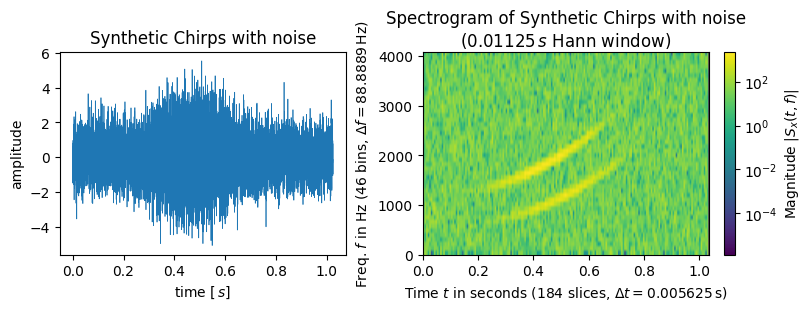

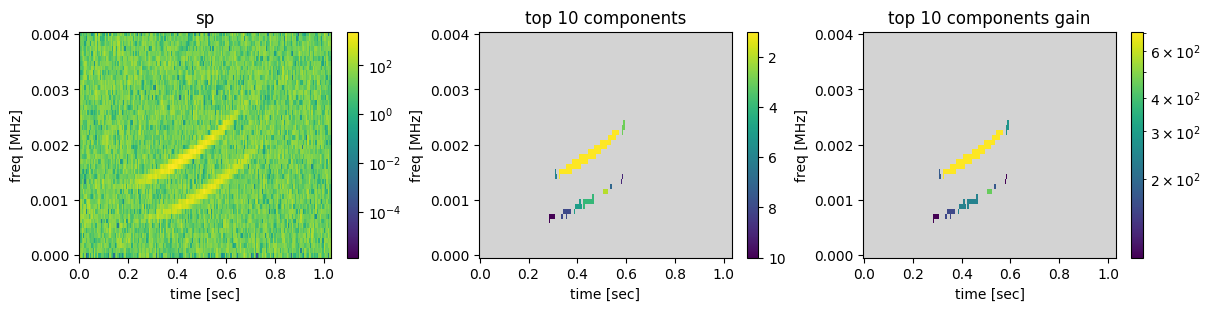

In [ ]:
# @title Synthetic data example of max_tree and optimum components using Chirp object and noise
# cell name: example_synthetic_chirp_signal_with_noise
# before running, run cell "machinery_and_utilities"

assert 'machinery_and_utilities' in locals(), 'must first run cell machinery_and_utilities'
example_synthetic_chirp_signal_with_noise=True

## begin make_example_synthetic_signal
doSignalPlot = True
doSignalSpectrogramPlot = True
vsz,hsz = 3,4

nt=8192
dt=1.0/8000.0
t=np.arange(0,nt*dt,dt)
nt=len(t)
dt=t[1]-t[0]
fs=1/dt
fN = fs/2.0
nfft=int(np.ceil(np.sqrt(nt)))
noise_mean=0
noise_std=1.0

chirps=[]

t0=t[int(nt/16)]
t1=t[int(nt/16)+int(nt*3/4)-1]
chirps.append(Chirp(amp=2.0, t0=t0, t1=t1, f0=0.3*fN, f1=0.9*fN))

t0=t[int(nt/8)]
t1=t[int(nt/8)+int(nt*3/4)-1]
chirps.append(Chirp(amp=1.5, t0=t0, t1=t1, f0=0.15*fN, f1=0.7*fN))

sig0 = add_funcsigs(chirps,t)
#sig0 = 0*t

seedGlobal=getSavedRndGenSeed()
useSavedRndGenSeed = True
noise_generator = np.random.default_rng(seed=seedGlobal if useSavedRndGenSeed else None).normal
noise = make_noise(noise_mean, noise_std, t.shape, noise_generator=noise_generator )
sig = sig0 + noise

sigtit='Synthetic Chirps with noise'
from scipy.signal import ShortTimeFFT
t0=t[0]
nt=len(t)
dt=t[1]-t[0]
fs=1/dt
fN = fs/2.0
nfft=(int(np.ceil(np.sqrt(nt))) // 2) * 2
noverlap=int(nfft/2)

SFT = ShortTimeFFT.from_window(win_param='hann', fs=fs, nperseg=nfft,noverlap=noverlap)
sigstft = SFT.stft(sig)
fsigstft = SFT.f
tsigstft = SFT.t(sig.size)

if doSignalPlot or doSignalSpectrogramPlot:
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec
    nr,nc = 1,doSignalPlot+doSignalSpectrogramPlot
    fig = plt.figure(figsize=(nc*hsz,nr*vsz),layout='constrained')
    gs = GridSpec(nr,nc, figure=fig)
    ipanel = 0

    if doSignalPlot:
        ax = fig.add_subplot(gs[0,ipanel])
        ipanel+=1
        plt.plot(t,sig,'-',linewidth=0.5)
        plt.title(sigtit,wrap=True)
        plt.xlabel(rf'time [$\,s$]')
        plt.ylabel('amplitude')

    if doSignalSpectrogramPlot:
        from matplotlib.colors import LogNorm
        ax1 = fig.add_subplot(gs[0,ipanel])
        ipanel+=1

        kwextra = {}
        vlimdict = {}
        normfunc = LogNorm
        norm = normfunc(**vlimdict)
        #cmstd = cmapIDL_Standard_Gamma_II()
        #cmap = cmstd
        cmap ='viridis'

        N=nt
        t_lo, t_hi = SFT.extent(N)[:2]  # time range of plot
        ax1.set_title(rf"Spectrogram of {sigtit}"+"\n"+rf"({SFT.m_num*SFT.T:g}$\,s$ Hann window)",wrap=True)
        ax1.set(xlabel=f"Time $t$ in seconds ({SFT.p_num(N)} slices, " +
                      rf"$\Delta t = {SFT.delta_t:g}\,$s)",
                ylabel=f"Freq. $f$ in Hz ({SFT.f_pts} bins, " +
                      rf"$\Delta f = {SFT.delta_f:g}\,$Hz)",
                xlim=(t_lo, t_hi))

        im1 = ax1.imshow(np.abs(sigstft)**2, origin='lower', aspect='auto',
                        extent=SFT.extent(N), cmap=cmap, norm=norm,**kwextra)
        plotLeg=False
        if (False):
            ##need to define "chirpfreqs" before using.  "chripfreqs" should be chirp frequencies vs t)
            ax1.plot(t, chirpfreqs, 'r--', alpha=.5, label='$f_i(t)$')
            plotLeg=True

        plt.colorbar(im1, label="Magnitude $|S_x(t, f)|$")

        if (False):
            # Shade areas where window slices stick out to the side:
            for t0_, t1_ in [(t_lo, SFT.lower_border_end[0] * SFT.T),
                            (SFT.upper_border_begin(N)[0] * SFT.T, t_hi)]:
                ax1.axvspan(t0_, t1_, color='w', linewidth=0, alpha=.2)
            for t_ in [0, N * SFT.T]:  # mark signal borders with vertical line:
                ax1.axvline(t_, color='y', linestyle='--', alpha=0.5)

        if plotLeg: ax1.legend()

## end make_example_synthetic_signal

## begin max_tree_optimimum_features

max_tree_cl = Max_Tree
sp = np.abs(sigstft)**2
fsp = fsigstft
tsp = tsigstft

spmxtr=max_tree_cl(sp,connectivity=2)
self=spmxtr

#gain_choice='avspecdens'
gain_choice = 'avspecheight'
gain = self.gain_predefined(gain_choice)
mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)

ntop=10
_ = show_top_components_rank_and_gain(sp,mxgnndslabeltopfill,mxgntopfill,ntop=ntop,panelsize=(vsz,hsz))



## end max_tree_optimimum_features


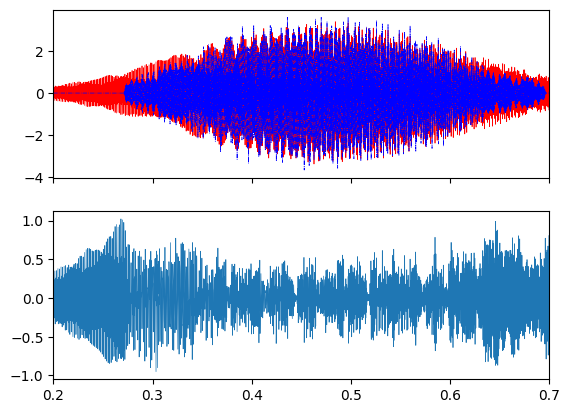

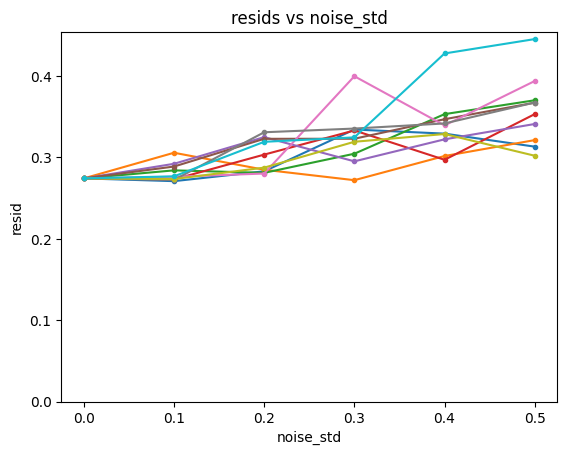

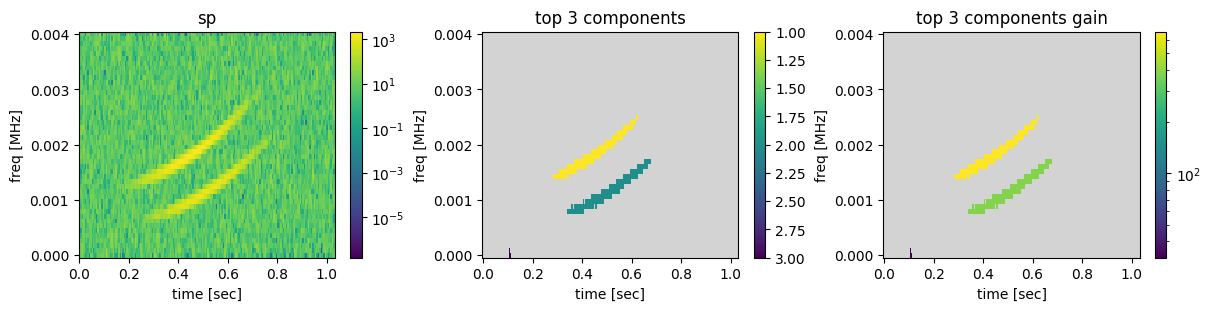

In [ ]:
# @title Statistics of chirp extraction with max-tree optimum components
# cell name: statistics_of_chirp_extraction_with_max_tree_optimum_components
# before running, run cell "machinery_and_utilities"

assert 'machinery_and_utilities' in locals(), 'must first run cell machinery_and_utilities'
statistics_of_noise_max_tree_optimum_components=True

nt=8192
dt=1.0/8000.0
t=np.arange(0,nt*dt,dt)
nt=len(t)
dt=t[1]-t[0]
fs=1/dt
fN = fs/2.0
nfft=(int(np.ceil(np.sqrt(nt))) // 2) * 2
overlap = 0.5


chirps=[]

t0=t[int(nt/16)]
t1=t[int(nt/16)+int(nt*3/4)-1]
chirps.append(Chirp(amp=2.0, t0=t0, t1=t1, f0=0.3*fN, f1=0.9*fN))

t0=t[int(nt/8)]
t1=t[int(nt/8)+int(nt*3/4)-1]
chirps.append(Chirp(amp=1.5, t0=t0, t1=t1, f0=0.15*fN, f1=0.7*fN))

sig0 = add_funcsigs(chirps,t)
sigstft0,fsp,tsp = stft_sig(sig0,win_param='hann',fs=fs,nperseg=nfft,overlap=overlap)
sp0 = np.abs(sigstft0)**2

#ntop=10

useSavedRndGenSeed = True
noise_generator = np.random.default_rng(seed=getSavedRndGenSeed() if useSavedRndGenSeed else None).normal
mk_noise = lambda mn,std,shp: make_noise(mn,std,shp,noise_generator=noise_generator)


noise_mean=0
noise_stds = np.linspace(0,.5,6)

max_tree_cl = Max_Tree
#gain_choice = 'avspecdens'
gain_choice = 'avspecheight'
ntop = 3
ntrials = 10
resids = np.zeros((len(noise_stds),ntrials))

# save diagnostics for display
Save = True
saved=dict()
CompToSave = (len(noise_stds)-1,0)
toSave = { # key:val of form (iouter,itr):['var1',...])
    (0,0):['sig','sigfilt'],
    CompToSave:['sp','mxgnndslabeltopfill','mxgntopfill'],
  }

for iouter,noise_std in enumerate(noise_stds):
    for itr in range(ntrials):
        noise = mk_noise(noise_mean, noise_std, t.shape)
        sig = sig0 + noise

        sigstftn,_,_,SFT = stft_sig(noise,win_param='hann',fs=fs,nperseg=nfft,overlap=0.5,returnSFT=True)
        sigstft = sigstft0 + sigstftn
        sp = np.abs(sigstft)**2

        self=max_tree_cl(sp,connectivity=2)
        gain = self.gain_predefined(gain_choice)
        mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)

        filt = ((mxgnndslabeltopfill > 0) & (mxgnndslabeltopfill <= ntop))
        sigstftfilt = sigstft*filt
        sigfilt = SFT.istft(sigstftfilt,k1=nt)
        resids[iouter,itr] = np.sqrt(np.mean(np.abs(sigfilt-sig0)**2))
        if Save and (iouter,itr) in toSave:
            saved[(iouter,itr)] = {vk:globals()[vk] for vk in toSave[(iouter,itr)]}


if Save:
    # display saved diagnostics
    fig, (ax1,ax2) = plt.subplots(2,1,sharex=True)
    ax1.plot(t,saved[(0,0)]['sig'],'r',linewidth=0.5)
    ax1.plot(t,saved[(0,0)]['sigfilt'],'b-.',linewidth=0.5)
    ax2.plot(t,saved[(0,0)]['sigfilt']-saved[(0,0)]['sig'],linewidth=0.5)
    plt.xlim(np.array([0,.5])+0.2)

    fig, ax = plt.subplots()
    stdsig0 = np.sqrt(np.mean(np.abs(sig0)**2))
    ax.plot(noise_stds,resids/stdsig0,'.-')
    ax.set_title('resids vs noise_std')
    ax.set_xlabel('noise_std')
    ax.set_ylabel('resid')
    ax.set_ylim(bottom=0)

    _ = show_top_components_rank_and_gain(saved[CompToSave]['sp'],saved[CompToSave]['mxgnndslabeltopfill'],saved[CompToSave]['mxgntopfill'],ntop=ntop)


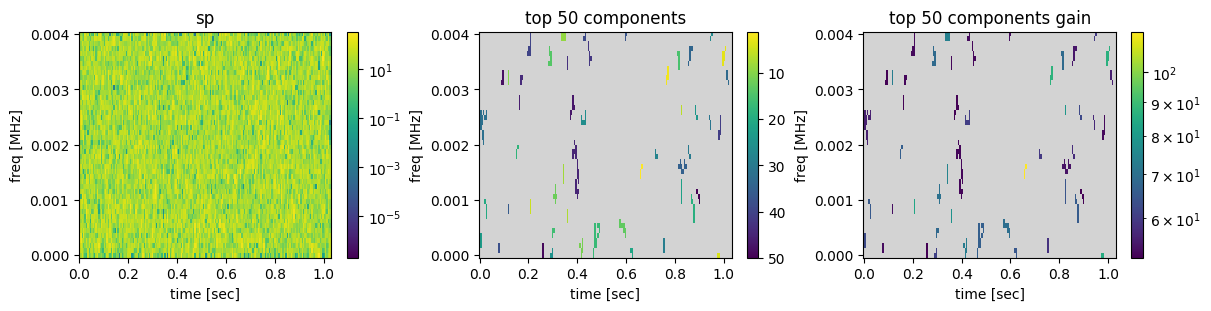

In [ ]:
# @title max_tree optimum components using just noise
# cell name: example_noise_max_tree_optimum_components
# before running, run cell "machinery_and_utilities"

assert 'machinery_and_utilities' in locals(), 'must first run cell machinery_and_utilities'
example_noise_max_tree_optimum_components=True

## begin make_example_synthetic_signal
doSignalPlot = False
doSignalSpectrogramPlot = False
vsz,hsz = 3,4

nt=8192
dt=1.0/8000.0
t=np.arange(0,nt*dt,dt)
nt=len(t)
dt=t[1]-t[0]
fs=1/dt
fN = fs/2.0
nfft=int(np.ceil(np.sqrt(nt)))
noise_mean=0
noise_std=1.0

chirps=[]
if False:
    t0=t[int(nt/16)]
    t1=t[int(nt/16)+int(nt*3/4)-1]
    chirps.append(Chirp(amp=2.0, t0=t0, t1=t1, f0=0.3*fN, f1=0.9*fN))

    t0=t[int(nt/8)]
    t1=t[int(nt/8)+int(nt*3/4)-1]
    chirps.append(Chirp(amp=1.5, t0=t0, t1=t1, f0=0.15*fN, f1=0.7*fN))

    sig0 = add_funcsigs(chirps,t)
    sigtit='Synthetic Chirps with noise'
else:
    sig0 = 0*t
    sigtit='Noise'


seedGlobal=getSavedRndGenSeed()
useSavedRndGenSeed = False
noise_generator = np.random.default_rng(seed=seedGlobal if useSavedRndGenSeed else None).normal
noise = make_noise(noise_mean, noise_std, t.shape, noise_generator=noise_generator )

sig = sig0 + noise

from scipy.signal import ShortTimeFFT
t0=t[0]
nt=len(t)
dt=t[1]-t[0]
fs=1/dt
fN = fs/2.0
nfft=(int(np.ceil(np.sqrt(nt))) // 2) * 2
noverlap=int(nfft/2)

SFT = ShortTimeFFT.from_window(win_param='hann', fs=fs, nperseg=nfft,noverlap=noverlap)
sigstft = SFT.stft(sig)
fsigstft = SFT.f
tsigstft = SFT.t(sig.size)

if doSignalPlot or doSignalSpectrogramPlot:
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec
    nr,nc = 1,doSignalPlot+doSignalSpectrogramPlot
    fig = plt.figure(figsize=(nc*hsz,nr*vsz),layout='constrained')
    gs = GridSpec(nr,nc, figure=fig)
    ipanel = 0

    if doSignalPlot:
        ax = fig.add_subplot(gs[0,ipanel])
        ipanel+=1
        plt.plot(t,sig,'-',linewidth=0.5)
        plt.title(sigtit,wrap=True)
        plt.xlabel(rf'time [$\,s$]')
        plt.ylabel('amplitude')

    if doSignalSpectrogramPlot:
        from matplotlib.colors import LogNorm
        ax1 = fig.add_subplot(gs[0,ipanel])
        ipanel+=1

        kwextra = {}
        vlimdict = {}
        normfunc = LogNorm
        norm = normfunc(**vlimdict)
        #cmstd = cmapIDL_Standard_Gamma_II()
        #cmap = cmstd
        cmap ='viridis'

        N=nt
        t_lo, t_hi = SFT.extent(N)[:2]  # time range of plot
        ax1.set_title(rf"Spectrogram of {sigtit}"+"\n"+rf"({SFT.m_num*SFT.T:g}$\,s$ Hann window)",wrap=True)
        ax1.set(xlabel=f"Time $t$ in seconds ({SFT.p_num(N)} slices, " +
                      rf"$\Delta t = {SFT.delta_t:g}\,$s)",
                ylabel=f"Freq. $f$ in Hz ({SFT.f_pts} bins, " +
                      rf"$\Delta f = {SFT.delta_f:g}\,$Hz)",
                xlim=(t_lo, t_hi))

        im1 = ax1.imshow(np.abs(sigstft)**2, origin='lower', aspect='auto',
                        extent=SFT.extent(N), cmap=cmap, norm=norm,**kwextra)
        plotLeg=False
        if (False):
            ##need to define "chirpfreqs" before using.  "chripfreqs" should be chirp frequencies vs t)
            ax1.plot(t, chirpfreqs, 'r--', alpha=.5, label='$f_i(t)$')
            plotLeg=True

        plt.colorbar(im1, label="Magnitude $|S_x(t, f)|$")

        if (False):
            # Shade areas where window slices stick out to the side:
            for t0_, t1_ in [(t_lo, SFT.lower_border_end[0] * SFT.T),
                            (SFT.upper_border_begin(N)[0] * SFT.T, t_hi)]:
                ax1.axvspan(t0_, t1_, color='w', linewidth=0, alpha=.2)
            for t_ in [0, N * SFT.T]:  # mark signal borders with vertical line:
                ax1.axvline(t_, color='y', linestyle='--', alpha=0.5)

        if plotLeg: ax1.legend()

## end make_example_synthetic_signal

## begin max_tree_optimimum_features

max_tree_cl = Max_Tree
sp = np.abs(sigstft)**2
fsp = fsigstft
tsp = tsigstft

spmxtr=max_tree_cl(sp,connectivity=2)
self=spmxtr

#gain_choice='avspecdens'
gain_choice = 'avspecheight'
gain = self.gain_predefined(gain_choice)
mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)

ntop=50
_  = show_top_components_rank_and_gain(sp,mxgnndslabeltopfill,mxgntopfill,ntop=ntop,panelsize=(vsz,hsz))


## end max_tree_optimimum_features

In [48]:
# @title Statistics of max_tree optimum components using just noise
# cell name: statistics_of_noise_max_tree_optimum_components
# before running, run cell "machinery_and_utilities"

assert 'machinery_and_utilities' in locals(), 'must first run cell machinery_and_utilities'
statistics_of_noise_max_tree_optimum_components=True

nt=8192
dt=1.0/8000.0
t=np.arange(0,nt*dt,dt)
nt=len(t)
dt=t[1]-t[0]
fs=1/dt
fN = fs/2.0
nfft=(int(np.ceil(np.sqrt(nt))) // 2) * 2
overlap = 0.5

noiseonly = True
if not noiseonly:
    chirps=[]

    t0=t[int(nt/16)]
    t1=t[int(nt/16)+int(nt*3/4)-1]
    chirps.append(Chirp(amp=2.0, t0=t0, t1=t1, f0=0.3*fN, f1=0.9*fN))

    t0=t[int(nt/8)]
    t1=t[int(nt/8)+int(nt*3/4)-1]
    chirps.append(Chirp(amp=1.5, t0=t0, t1=t1, f0=0.15*fN, f1=0.7*fN))

    sig0 = add_funcsigs(chirps,t)
else:
    sig0 = 0*t

sigstft0,fsp,tsp = stft_sig(sig0,win_param='hann',fs=fs,nperseg=nfft,overlap=0.5)
sp0 = np.abs(sigstft0)**2

useSavedRndGenSeed = True
noise_generator_core = np.random.default_rng(seed=getSavedRndGenSeed() if useSavedRndGenSeed else None)
noise_generator_type = 'normal'

##not using a global mk_noise. Will have on for each trial, below
#noise_generator = getattr(noise_generator_core,noise_generator_type)
#mk_noise = lambda: make_noise(noise_mean,noise_std,noise_shape,noise_generator=noise_generator)

noise_mean=0
#noise_stds = np.linspace(0,.5,6)
noise_stds = np.array([1.0])
noise_shape = t.shape
nstds = len(noise_stds)

max_tree_cl = Max_Tree
gain_choice = 'avspecdens'
#gain_choice = 'avspecheight'
ntrials = 1600

#areas statistics. method relies on integer nature of area values.
import scipy.sparse as sprs
areas = []
area_counts = []

#max_gain statistics
max_gain_vals = []
max_gain_hist = []

#extents statistics
extents = []
extents_hist= []

#volume statistics
volumes = []
volume_hist = []

#height statistics
heights = []
height_hist = []

# save diagnostics for display
Save = True
CompToSave = (len(noise_stds)-1,0)
toSave = { # key:val of form (iouter,itr):['var1',...])
  }

Savers = []
maxCompSav = 3
def _(locs = None):
    mxgnndinds = locs['mxgnndinds']
    ret = dict()
    if len(mxgnndinds)  <= maxCompSav:
        cToSave = ['self','gain','mxgnndinds']
        ret = {vk:locs[vk] for vk in cToSave}
    return ret

Savers.append(_)

evalParallelPerformance = False
if evalParallelPerformance:
    import os
    import time

# trial task packaged as function, to allow multiple trials via map semantics
def trial(itr,noise_generator):
    ## the following variables should be defined in an outer scope:
    #    sig0,sigstft0,fs,nfft,overlap # signal (noiseless) and stft parameters
    #    noise_mean,noise_std,noise_shape,noise_generator # parameters for make_noise
    #    Save,iouter,toSave,Savers # controls for saving internal state for debug/examination

    if evalParallelPerformance:
        tmin = time.time() # for performance measurement

    noise = make_noise(noise_mean,noise_std,noise_shape,noise_generator=noise_generator)
    sig = sig0+noise

    sigstftn,_,_,SFT = stft_sig(noise,win_param='hann',fs=fs,nperseg=nfft,overlap=overlap,returnSFT=True)
    sigstft = sigstft0 + sigstftn
    sp = np.abs(sigstft)**2
    self=max_tree_cl(sp,connectivity=2)
    gain = self.gain_predefined(gain_choice)
    mxgnnds = self.maxattrnodes(gain) # Find nodes which are local maxima of gain along lineage.
    mxgnnds = self.optimummaxattrnodes(gain,maxattrnodes=mxgnnds) #prune gain-maximum nodes to leave only nodes with no descencdent having higher gain. has shape of gain, with nonzero values for only surviving nodes
    mxgnndinds = np.flatnonzero(mxgnnds * self.canonicality) # nonzero nodes mxgnnds are the winners of the pruning. get their indices. exclude non-canonical nodes.

    #max_gain statistics
    mxgnvls = gain.ravel()[mxgnndinds]

    #extents satistics
    exts = ravel_vec(self.extents)[mxgnndinds]

    #vol statistics
    vols = self.volume.ravel()[mxgnndinds]

    #height statistics
    hghts = self.height.ravel()[mxgnndinds]

    #areas statistics. method relies on integer nature of area values.
    #arcnts.append(sprs.coo_array((np.ones_like(mxgnndinds),(np.zeros_like(mxgnndinds),self.area.ravel()[mxgnndinds]-1)),(1,sp.size)))
    arcnts = sprs.csc_array((np.ones_like(mxgnndinds),(np.zeros_like(mxgnndinds),self.area.ravel()[mxgnndinds]-1)),(1,sp.size))
    arcnts.sum_duplicates() # for any sparse array type
    arcnts.sort_indices() # for csc_array or csr_array only
    ars = self.area.ravel()[mxgnndinds]

    ret = dict(mxgnvls=mxgnvls,arcnts=arcnts,ars=ars,exts=exts,vols=vols,hghts=hghts)
    if Save:
        saves = dict()
        saveKey = (iouter,itr)
        if Save and saveKey in toSave:
            saves.update({vk:globals()[vk] for vk in toSave[saveKey]})
        if Save and len(Savers) > 0:
            lock = list(locals().keys())
            locs={k:locals()[k] for k in lock}
            for s in Savers: saves.update(s(locs=locs))
        if len(saves) > 0: ret['saved'] = {saveKey:saves}

    if evalParallelPerformance:
        tmout = time.time() # for performance measurement
        ret['tm'] = (tmin,tmout)
        ret['pid'] = os.getpid() # for performance measurement

    return ret

timePerformance = False
for iouter,noise_std in enumerate(noise_stds):
    iouter = iouter # needed in "outer scope" by function "trial"

    noise_generators = [getattr(ngc,noise_generator_type) for ngc in noise_generator_core.spawn(ntrials)] # 1 generator per noise trial.  maybe allows speedup in parallel processing of trials

    if evalParallelPerformance:
        tmst = time.time() # for performance measurement

    useParallelProcessing = True  #tests on google colab show no speedup with parallel processing, but keeping it around in case it will help on OMFIT
    nParallel = 16
    if useParallelProcessing:
        from multiprocessing import Pool
        with Pool(nParallel) as pool:
            if timePerformance:
                %time ret_trials = list(pool.starmap(trial,zip(range(ntrials),noise_generators)))
            else:
                ret_trials = list(pool.starmap(trial,zip(range(ntrials),noise_generators)))
    else:
        if timePerformance:
            %time ret_trials = list(map(trial,range(ntrials),noise_generators))
        else:
            ret_trials = list(map(trial,range(ntrials),noise_generators))

    arcnts = []
    ars = []
    mxgnvls = []
    exts = []
    vols = []
    hghts = []
    saved=dict()

    for ret in ret_trials:
        arcnts.append(ret['arcnts'])
        ars.append(ret['ars'])
        mxgnvls.append(ret['mxgnvls'])
        exts.append(ret['exts'])
        vols.append(ret['vols'])
        hghts.append(ret['hghts'])
        if Save and 'saved' in ret:
            saved.update(ret.pop('saved'))

    #areas statistics. method relies on integer nature of area values.
    areas.append(ars)
    area_counts.append(sprs.vstack(arcnts))

    #max_gain statistics
    max_gain_vals.append(mxgnvls)
    mxgnhist,mxgnedgs = np.histogram(np.concatenate(mxgnvls),bins='auto')
    max_gain_hist.append((mxgnhist,mxgnedgs))

    #extents statistics
    extents.append(exts)
    extsshist,extsedgs = list(zip(*[np.histogram(e,bins='auto') for e in np.concatenate(exts).T])) #notes that the "extents" statistic is a 2 element vector, in contrast with area another scalar statistics.  need to handled the vectorness of the statics here
    extents_hist.append((extsshist,extsedgs))

    #volume statistics
    volumes.append(vols)
    volshist,volsedgs = np.histogram(np.concatenate(vols),bins='auto')
    volume_hist.append((volshist,volsedgs))

    #height statistics
    heights.append(hghts)
    hghtshist,hghtsedgs = np.histogram(np.concatenate(hghts),bins='auto')
    height_hist.append((hghtshist,hghtsedgs))

#areas statistics. method relies on integer nature of area values.
area_hist = np.stack([ac.sum(axis=0).ravel() for ac in area_counts],axis=0)
area_prob = area_hist/np.sum(area_hist,axis=1,keepdims=True)

if evalParallelPerformance:
    #load spread on processes
    tmin,tmout = [np.array(t)-tmst for t in list(zip(*[r['tm'] for r in ret_trials]))]
    fig = plt.figure(figsize=(8,4),layout='constrained')
    fig.add_subplot(1,2,1)
    plt.hlines([r['pid'] for r in ret_trials],tmin,tmout)
    plt.xlabel('time (s)')
    plt.ylabel('suprocess id')

    fig.add_subplot(1,2,2)
    tm = np.stack([tmin,tmout],axis=0).ravel()
    incr = np.repeat(np.array([1,-1])[:,np.newaxis],tm.size/2,axis=1).ravel()
    iordtm = np.argsort(tm)
    tm = tm[iordtm]
    incr = incr[iordtm]
    cnt = np.cumsum(incr,)
    plt.plot(tm,cnt)
    plt.xlabel('time (s)')
    plt.ylabel('process count')
    plt.suptitle('processing load')


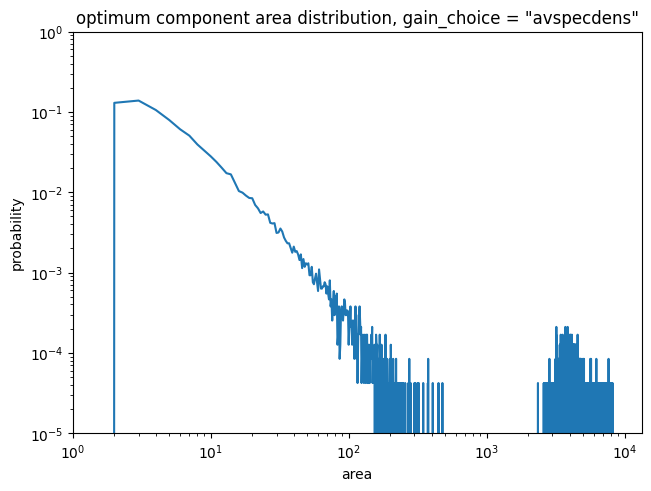

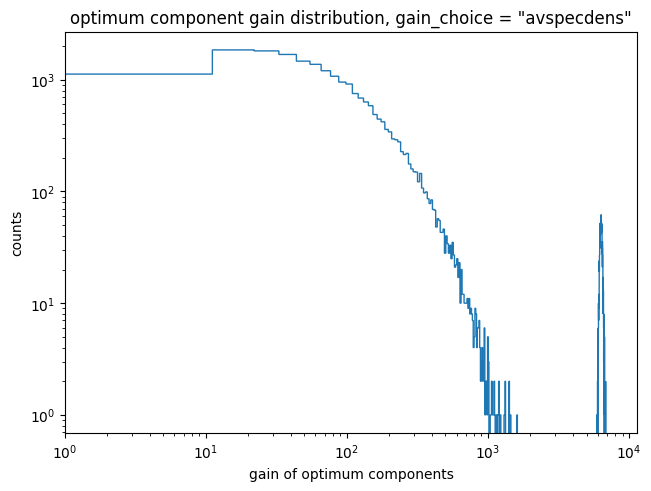

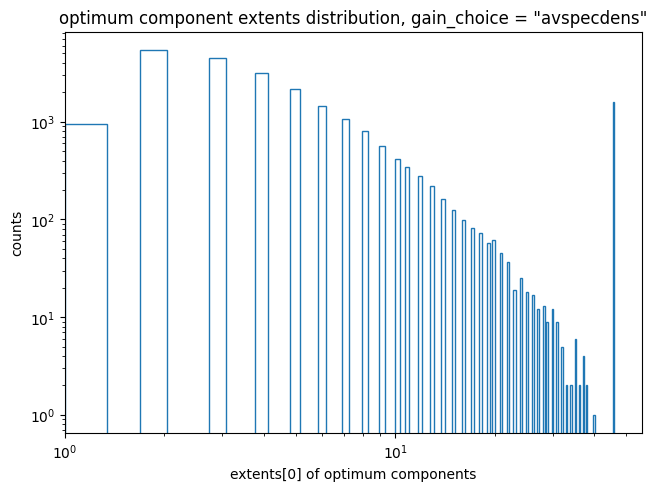

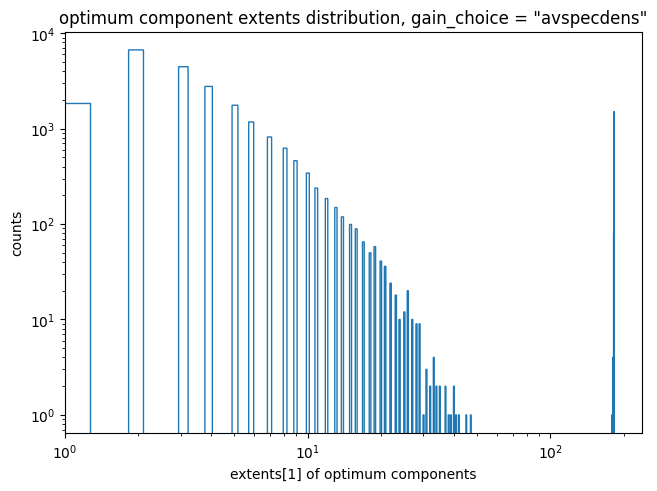

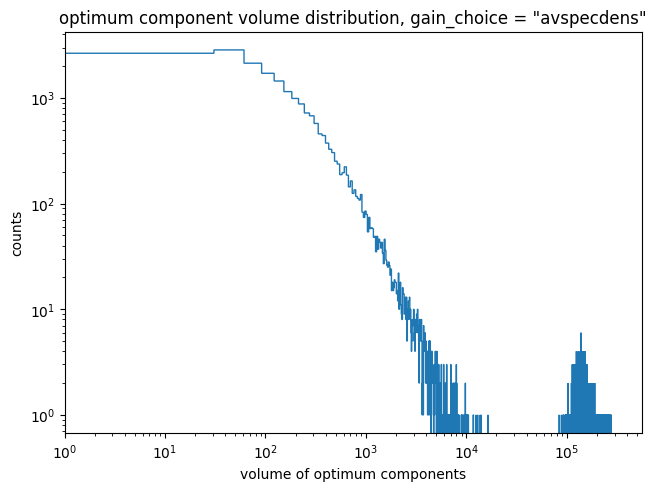

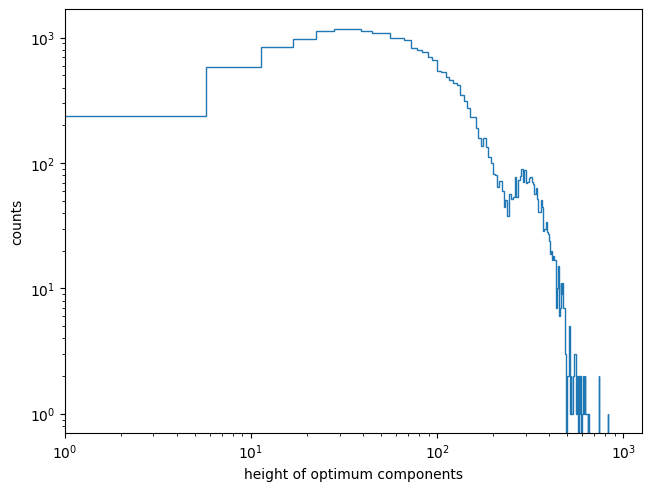

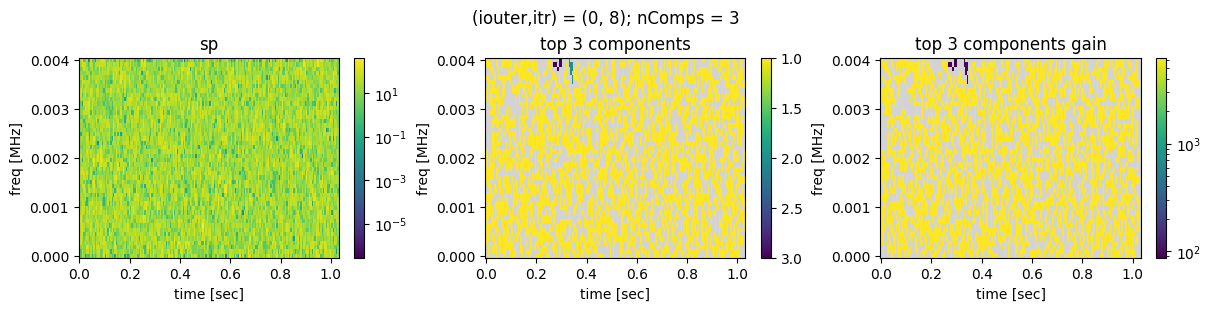

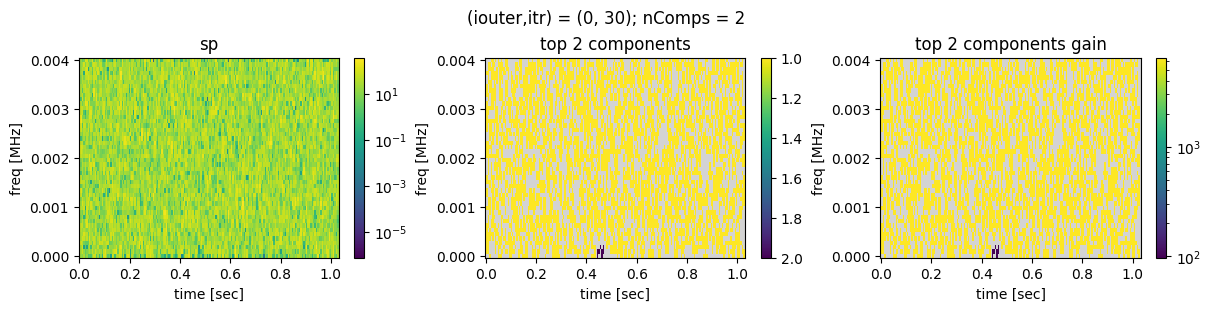

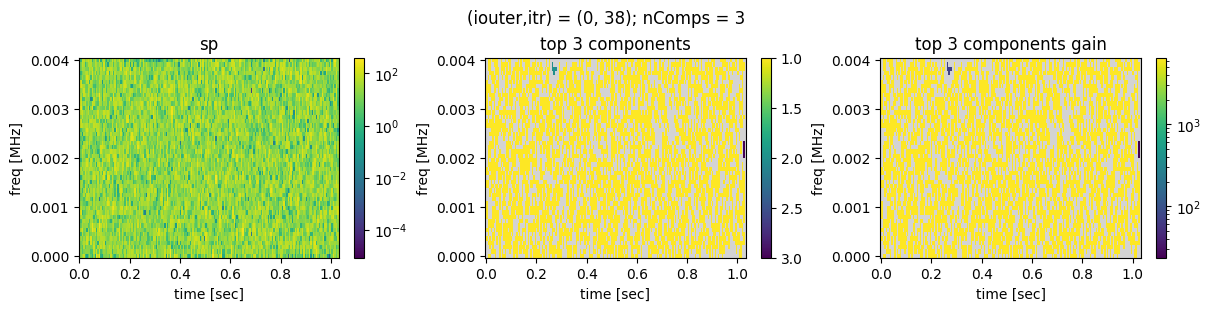

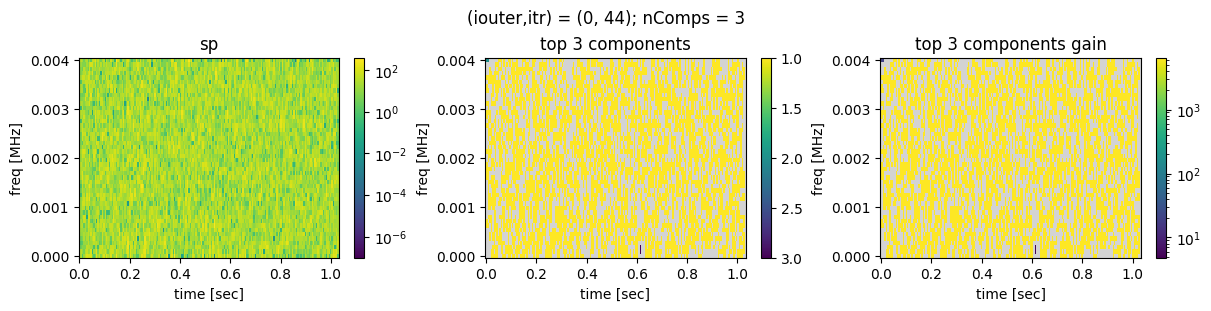

In [70]:

iouter = nstds-1
#area statistics
fig = plt.figure(layout='constrained')
plt.plot(np.arange(area_prob[iouter].shape[-1])+1,area_prob[iouter].T)
plt.yscale('log')
plt.xscale('log')
plt.xlim(xmin=1)
plt.ylim([.00001,1])
plt.xlabel('area')
plt.ylabel('probability')
plt.title(f'optimum component area distribution, gain_choice = "{gain_choice}"')

#max_gain statistics
fig = plt.figure(layout='constrained')
plt.stairs(max_gain_hist[iouter][0],max_gain_hist[iouter][1])
plt.yscale('log')
plt.xscale('log')
plt.xlim(xmin=1)
#plt.xlim([1,1000])
#plt.ylim([.00001,1])
plt.xlabel('gain of optimum components')
plt.ylabel('counts')
plt.title(f'optimum component gain distribution, gain_choice = "{gain_choice}"')

#extents statistics
for iext in [0,1]:
    fig = plt.figure(layout='constrained')
    plt.stairs(extents_hist[iouter][0][iext],extents_hist[iouter][1][iext])
    plt.yscale('log')
    plt.xscale('log')
    plt.xlim(xmin=1)
    plt.xlabel(f'extents[{iext}] of optimum components')
    plt.ylabel('counts')
    plt.title(f'optimum component extents distribution, gain_choice = "{gain_choice}"')

#volume statistics
fig = plt.figure(layout='constrained')
plt.stairs(volume_hist[iouter][0],volume_hist[iouter][1])
plt.yscale('log')
plt.xscale('log')
plt.xlim(xmin=1)
plt.xlabel('volume of optimum components')
plt.ylabel('counts')
plt.title(f'optimum component volume distribution, gain_choice = "{gain_choice}"')

#height statistics
fig = plt.figure(layout='constrained')
plt.stairs(height_hist[iouter][0],height_hist[iouter][1])
plt.yscale('log')
plt.xscale('log')
plt.xlim(xmin=1)
plt.xlabel('height of optimum components')
plt.ylabel('counts')

if Save:
    # display saved diagnostics

    compssav = {k:v  for k,v in saved.items() if 'mxgnndinds' in v}
    ncompssav = {k:len(v['mxgnndinds']) for k,v in saved.items() if 'mxgnndinds' in v}
    compssavk = list(compssav.keys())

    maxToShow = 4
    ToShow = [k for k in compssavk if ncompssav[k] > 1]
    ToShow = ToShow[0:min(len(ToShow),maxToShow)]
    for i,kTS in enumerate(ToShow):
        self,gain,mxgnndinds = [compssav[kTS][k] for k in ['self','gain','mxgnndinds']]

        mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)
        _ = show_top_components_rank_and_gain(self.image,mxgnndslabeltopfill,mxgntopfill,ntop=len(mxgnndinds))
        plt.suptitle(f'(iouter,itr) = {compssavk[i]}; nComps = {len(mxgnndinds)}')


In [69]:
max_gain_hist[0] = (max_gain_hist[0][1],max_gain_hist[0][0])

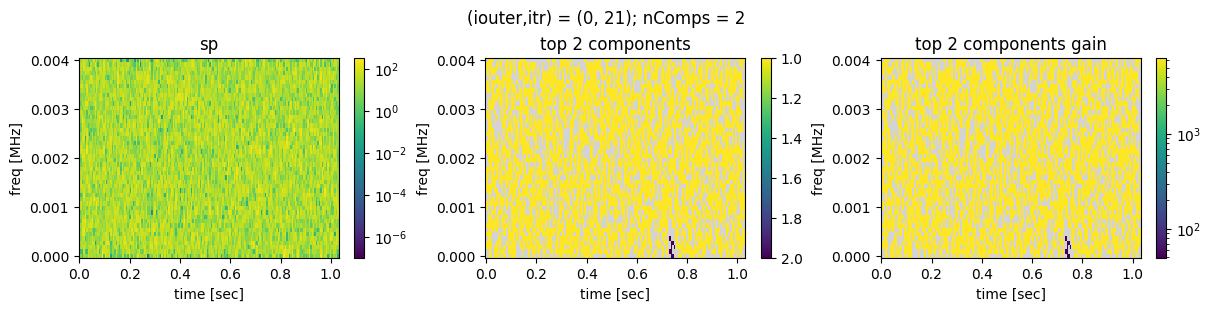

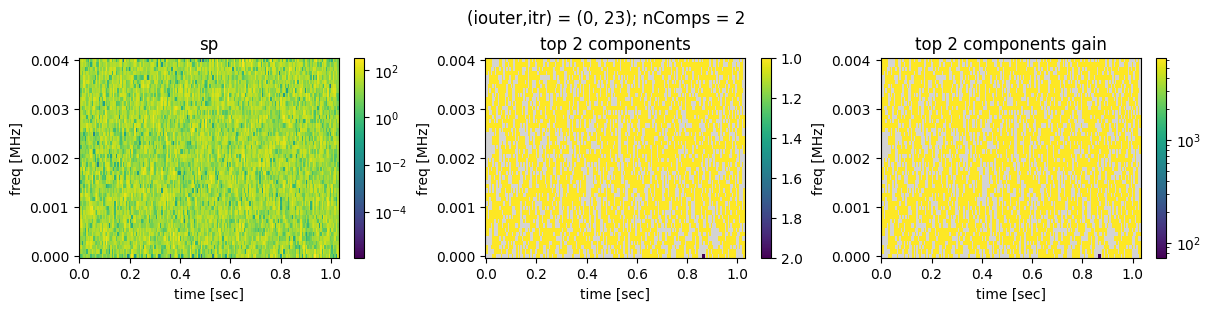

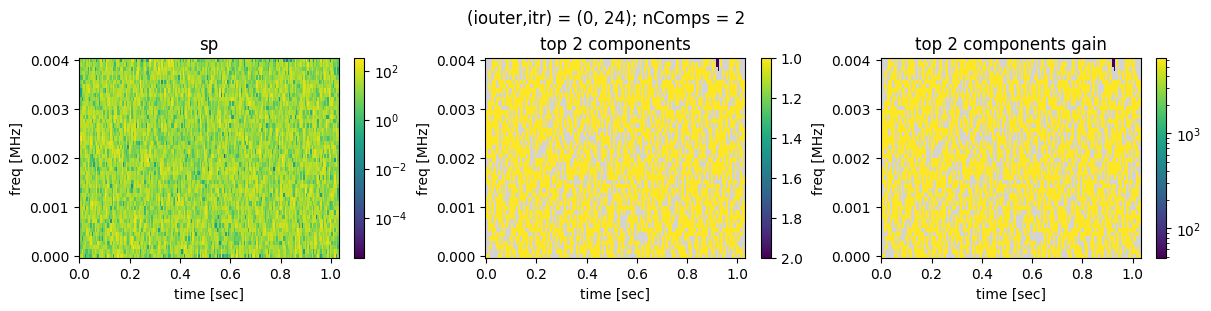

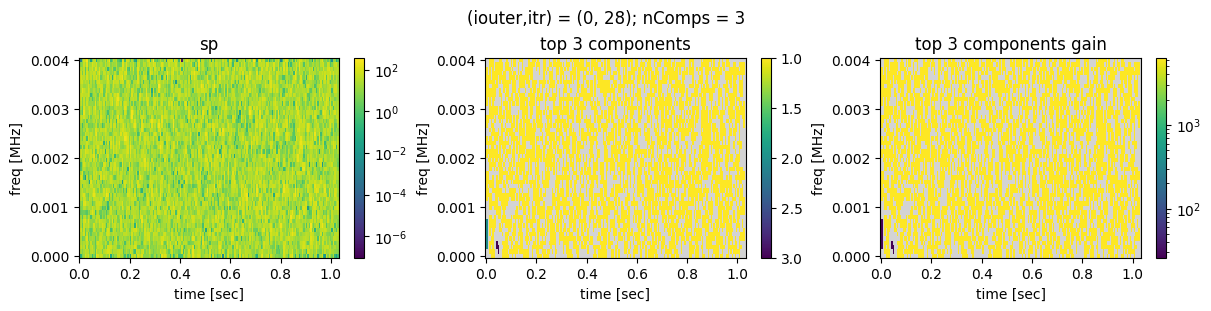

In [27]:
if Save:
    # display saved diagnostics

    compssav = {k:v  for k,v in saved.items() if 'mxgnndinds' in v}
    ncompssav = {k:len(v['mxgnndinds']) for k,v in saved.items() if 'mxgnndinds' in v}
    compssavk = list(compssav.keys())

    maxToShow = 4
    ToShow = [k for k in compssavk if ncompssav[k] > 1]
    ToShow = ToShow[0:min(len(ToShow),maxToShow)]
    for i,kTS in enumerate(ToShow):
        self,gain,mxgnndinds = [compssav[kTS][k] for k in ['self','gain','mxgnndinds']]

        mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)
        _ = show_top_components_rank_and_gain(self.image,mxgnndslabeltopfill,mxgntopfill,ntop=len(mxgnndinds))
        plt.suptitle(f'(iouter,itr) = {compssavk[i]}; nComps = {len(mxgnndinds)}')

In [47]:
exts = ravel_vec(self.extents)
exts = [exts[[0,1,2,3]],exts[[5,6,7]]]
h,e = list(zip(*[np.histogram(e,bins='auto') for e in np.concatenate(exts).T]))
h,e

((array([2, 0, 0, 5]), array([2, 0, 0, 5])),
 (array([ 1.  , 12.25, 23.5 , 34.75, 46.  ]),
  array([  1. ,  46.5,  92. , 137.5, 183. ])))

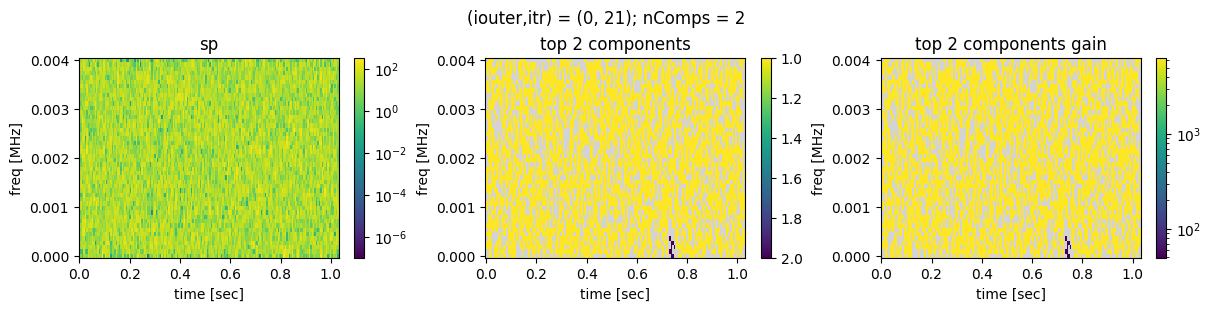

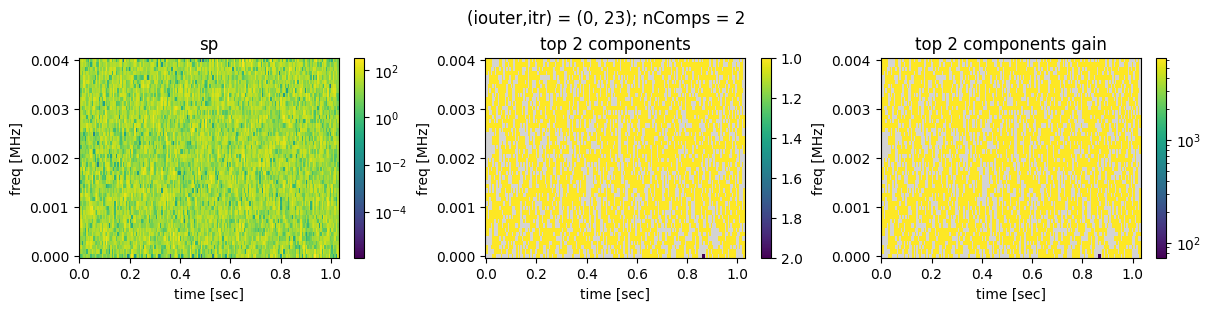

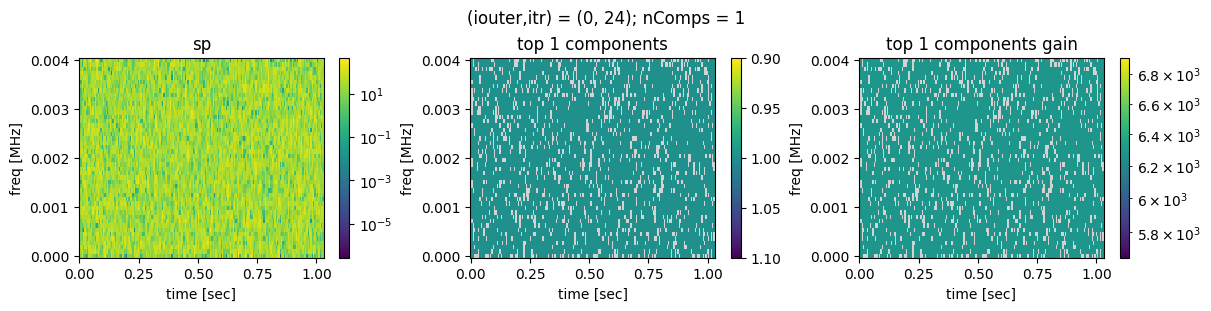

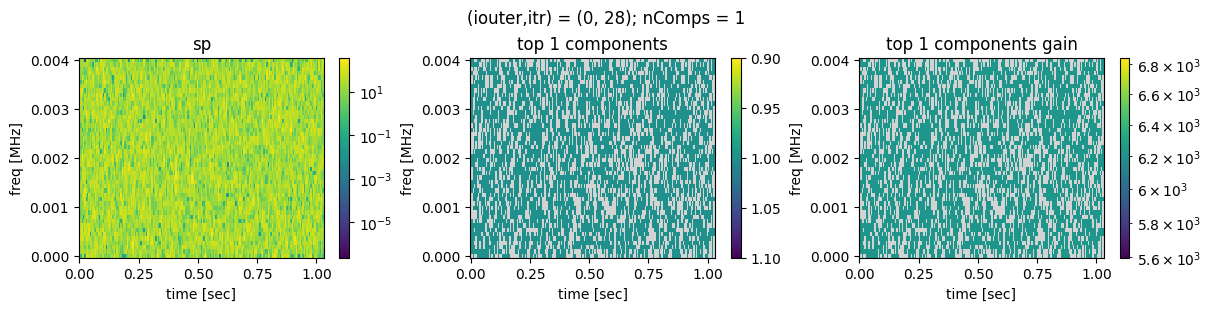

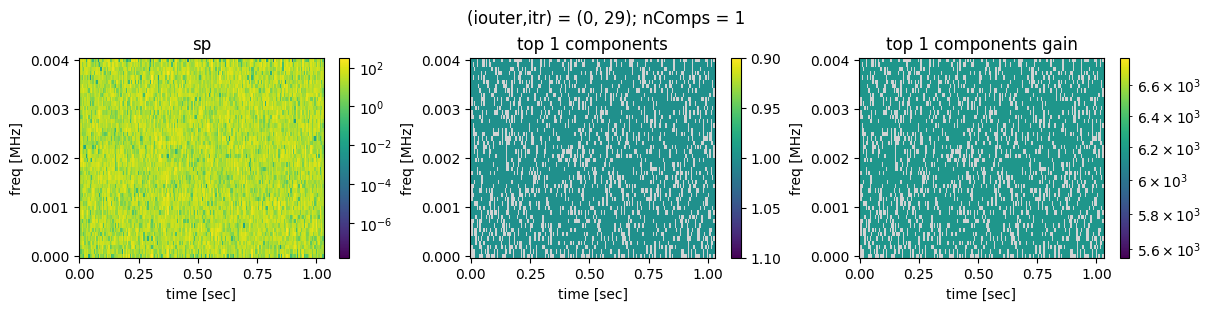

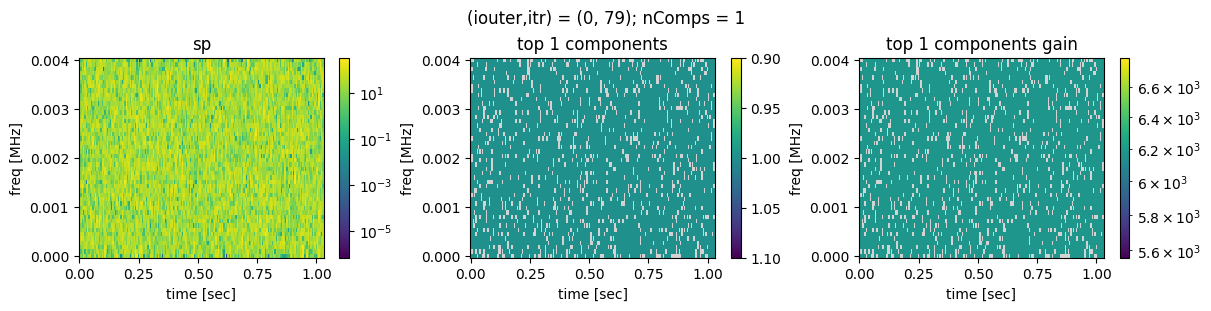

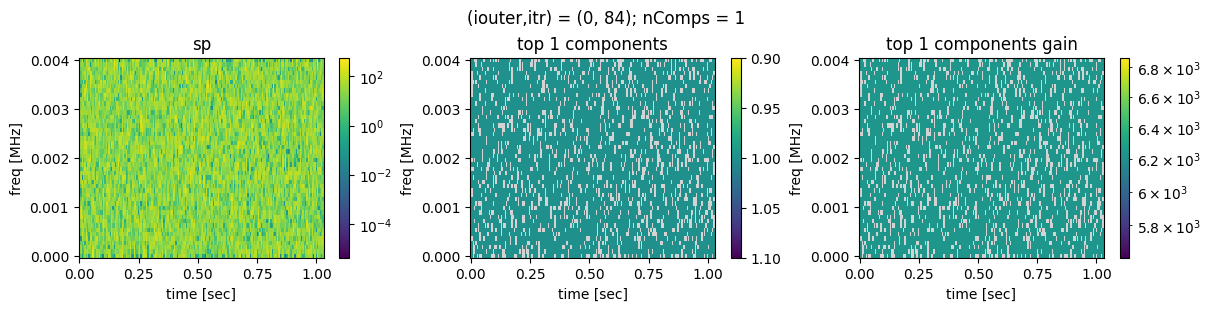

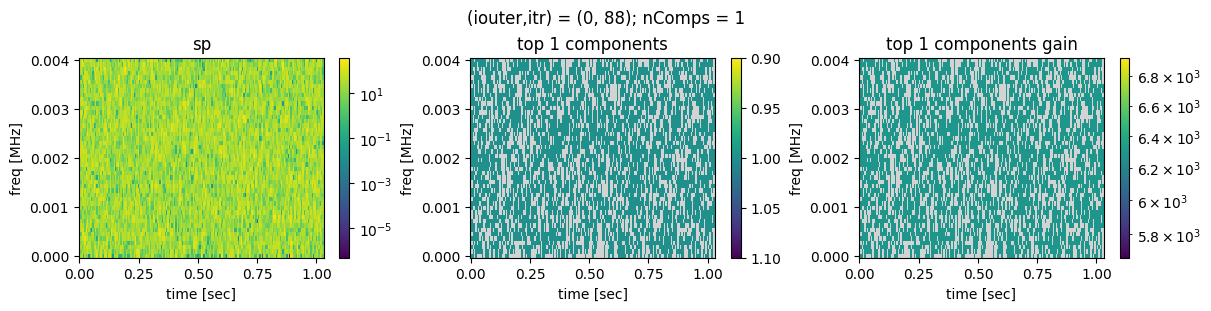

In [7]:
# @title Top components when there are 3 or few top components
if Save:
    # display saved diagnostics

    compssav = {k:v  for k,v in saved.items() if 'mxgnndinds' in v}
    ncompssav = {k:len(v['mxgnndinds']) for k,v in saved.items() if 'mxgnndinds' in v}
    compssavk = list(compssav.keys())

    maxToShow = 8
    nToShow = min(maxToShow,len(compssavk))

    for i in range(nToShow):
        self,gain,mxgnndinds = [compssav[compssavk[i]][k] for k in ['self','gain','mxgnndinds']]

        mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)
        _ = show_top_components_rank_and_gain(self.image,mxgnndslabeltopfill,mxgntopfill,ntop=len(mxgnndinds))
        plt.suptitle(f'(iouter,itr) = {compssavk[i]}; nComps = {len(mxgnndinds)}')

Text(0, 0.5, 'gain_vals')

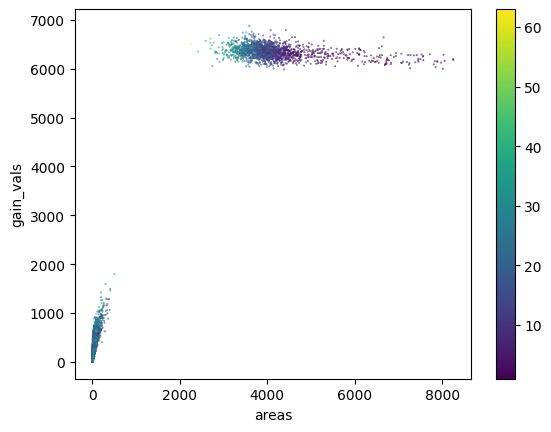

In [25]:
areas = area_counts_raw
ncomps = np.concatenate([[len(m)]*len(m) for m in max_gain_vals[0]])
sc = plt.scatter(np.concatenate(areas[0]),np.concatenate(max_gain_vals[0]),s=.1,c=ncomps)
plt.colorbar(sc)
plt.xlabel('areas')
plt.ylabel('gain_vals')

# Extras

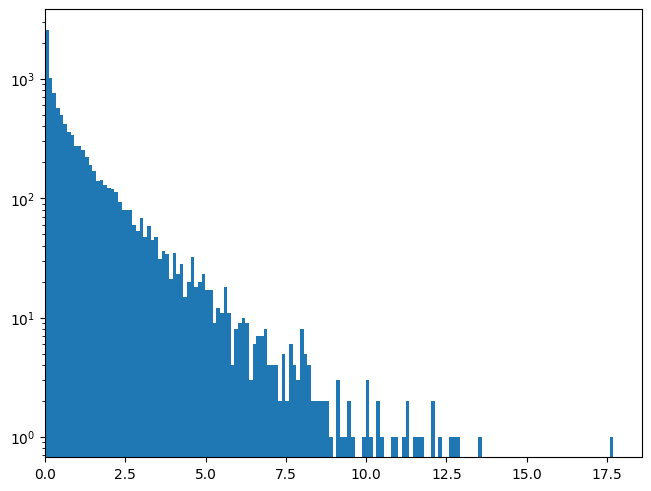

In [ ]:
# @title statistical explorations
import numpy as np
import matplotlib.pyplot as plt

ndegfreedom=1
rng = lambda size: np.random.default_rng().chisquare(df=ndegfreedom,size=size)

fig =  plt.figure(layout='constrained')
ax = fig.add_subplot()
_=ax.hist(rng(10000),bins='auto')
ax.set_xlim(xmin=0)
ax.set_yscale('log')

In [ ]:
# @title Speed test for various sparse methods of histograming component area statistics
import scipy.sparse as sprs

seed = 12345
rng = np.random.default_rng(seed=seed)

ntrials = 100
sz=10000
thrsh = 900
doareas = True

def build_array(method=0,doareas=False,out=None,rng=rng):

    arcnts = []
    if doareas: areas = np.zeros((ntrials,sz),dtype=int)
    arcntsalt = np.zeros((ntrials,sz),dtype=int)

    for itr in range(ntrials):
        area = rng.integers(0,thrsh+sz,size=sz)
        area = (area-thrsh)*(area >= thrsh)
        if doareas: areas[itr,:] = area


        ind=np.flatnonzero(area)
        temp = np.zeros((sz,))
        np.add.at(temp,area[ind]-1,1)
        arcntsalt[itr,:] = temp

        if method == 0:
            methstr="coo + sum_duplicates approach"
            ind=np.flatnonzero(area)
            arcnts.append(sprs.coo_array((np.ones_like(ind),(np.zeros_like(ind),area[ind]-1)),(1,sz)))
            arcnts[-1].sum_duplicates()

        if method == 1:
            methstr="coo + bincount approach"
            ac = np.bincount(area)
            arcnts.append(sprs.coo_array((ac[1:],(np.zeros((len(ac)-1,),dtype=int),np.arange(len(ac)-1))),(1,sz)))
            arcnts[-1].eliminate_zeros()

        if method == 2:
            methstr="csr + sum_duplicates/sort_indices approach"
            ind=np.flatnonzero(area)
            arcnts.append(sprs.csr_array((np.ones_like(ind),(np.zeros_like(ind),area[ind]-1)),(1,sz)))
            arcnts[-1].sum_duplicates()
            arcnts[-1].sort_indices()

        if method == 3:
            methstr="csc + sum_duplicates/sort_indices approach"
            ind=np.flatnonzero(area)
            arcnts.append(sprs.csc_array((np.ones_like(ind),(np.zeros_like(ind),area[ind]-1)),(1,sz)))
            arcnts[-1].sum_duplicates()
            arcnts[-1].sort_indices()


    arcnts=sprs.vstack(arcnts)

    if isinstance(out,list) and len(out) == 0:
        out.append(methstr)
        out.append(arcnts)
        out.append(arcnts.sum(axis=0))
        out.append(arcnts.sum(axis=1))
        out.append(arcntsalt)
        if doareas: out.append(areas)

prunN = 100
nmeth = 4
ord = np.arange(nmeth)
np.random.default_rng().shuffle(ord)
outs = [None for i in range(nmeth)]
statsouts = [None for i in range(nmeth)]
for meth in ord:
    rng = np.random.default_rng(seed=seed)
    out = []
    print(meth)
    statsouts[meth] = %timeit -oqn100 build_array(method=meth,doareas=doareas,rng=rng,out=out)
    #statsouts[meth] = %prun -rq for i in range(prunN): build_array(method=meth,doareas=doareas,rng=rng,out=out)
    outs[meth] = out

print('')
import pstats
iord = np.argsort(ord)
acs = []
for meth in range(nmeth):
    methstr,arcnts,arcntssa0,arcntssa1,arcntsalt = outs[meth][0:-1]
    if doareas: areas = outs[meth][-1]
    print("method, sequence: ",methstr,", ",iord[meth])
    if isinstance(statsouts[meth],pstats.Stats):
        statsouts[meth].sort_stats(pstats.SortKey.CUMULATIVE).print_stats(.1)
    else:
        print(statsouts[meth])
    acs.append(arcnts)

allsprs = lambda x,y : (x!=y).count_nonzero() == 0
for meth in range(1,nmeth): print(meth,allsprs(acs[0],acs[meth]))


0
2
3
1

method, sequence:  coo + sum_duplicates approach ,  0
306 ms ± 14.2 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
method, sequence:  coo + bincount approach ,  3
193 ms ± 6.2 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
method, sequence:  csr + sum_duplicates/sort_indices approach ,  1
259 ms ± 988 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
method, sequence:  csc + sum_duplicates/sort_indices approach ,  2
232 ms ± 2.61 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
1 True
2 True
3 True


In [ ]:
# @title Demo of Synthetic chirp signals with Chirp objects
# cell name: demo_of_machinery_for_synthetic_chirp_signals_with_noise
# before running, run cell "machinery_and_utilities"

assert 'machinery_and_utilities' in locals(), 'must first run cell machinery_and_utilities'
demo_of_machinery_for_synthetic_chirp_signals_with_noise=True

t=np.linspace(-.1,1.1,25)+.05
chrpd0 = Chirp(t0=0.0,t1=1.0,f0=3.0,f1=3.0,phi=90.0)
chrpd1 = Chirp(amp=2.0,t0=0.1,t1=0.9,f0=5.0,f1=3.0,phi=90.0)

chrpds = [chrpd0,chrpd1]
sig = add_funcsigs(chrpds,t)

import matplotlib.pyplot as plt
plt.figure()
plt.plot(t,sig,'.-')

with np.printoptions(precision=2, linewidth=120):
    print(t)
    print(sig)

In [ ]:
# @title Legacy synthetic chirp signal machinery
import numpy as np
from scipy.signal import chirp

def blackman_vs_tau(tau):
    """Blackman window vs normalized time (0 <= tau <= 1)
       This gives numpy.blackman(M) == blackman_vs_tau(taus) for taus = (numpy.arange(1-M, M, 2)/(M-1)/2) + 0.5
    """
    return 0.42 + 0.5*np.cos(2*np.pi*(tau-0.5)) + 0.08* np.cos(4*np.pi*(tau-0.5)) #0 <= tau <= 1

def mkchirpdesc(amp=1.0,f0=.25,f1=.75,t0=.1,t1=0.9,phi=0.0,vert0=True):
    return dict(amp=amp,f0=f0,f1=f1,t0=t0,t1=t1,phi=phi,vert0=vert0)

def make_sig(t, chirpdescs = None, phi=0):
    nt=len(t)
    sig=np.zeros((nt,),dtype=float)
    t=np.asarray(t)

    if chirpdescs is None:
        return sig

    for imd,chrp in enumerate(chirpdescs):
        amp,f0,f1,t0,t1,phi,vert0=(chrp[k] for k in ['amp','f0','f1','t0','t1','phi','vert0'])

        it0 = np.searchsorted(t,t0)
        it1 = np.searchsorted(t,t1,side='right')-1
        ntch=it1-it0+1
        if ntch > 0:
            envl=blackman_vs_tau((t[it0:it0+ntch]-t0)/(t1-t0))
            sig[it0:it0+ntch]+=amp*envl*chirp(t[it0:it0+ntch]-t0, f0, t1-t0, f1, method='quadratic', phi=phi, vertex_zero=vert0)
        return sig

import matplotlib.pyplot as plt
t=np.linspace(-.1,1.1,25)+.05
chrpd0 = mkchirpdesc(t0=0.0,t1=1.0,f0=3.0,f1=3.0,phi=90.0)
chrpds = [chrpd0]
sig = make_sig(t,chrpds)
plt.figure()
plt.plot(t,sig,'.-')
with np.printoptions(precision=2, linewidth=120):
    print(t)
    print(sig)

# Scrap Code

In [ ]:
# @title coo_builder (probably useless)
class coo_builder:
    def __init__(self):
        self.data =  []
        self.rowinds =  []
        self.colinds =  []

    def add_data(self,data,inds):
        self.data.append(data)
        self.rowinds.append(inds[0])
        self.colinds.append(inds[1])

    def build_coo(self,shape=None):
        import scipy.sparse as sprs
        return sprs.coo_array(np.concatenate(self.data),(np.concatenate(self.rowinds),np.concatenate(self.colinds)),shape)


In [ ]:
# @title  max_tree with optimum components

max_tree_cl = Max_Tree
sp = np.abs(sigstft)**2
fsp = fsigstft
tsp = tsigstft

spmxtr=max_tree_cl(sp,connectivity=2)
self=spmxtr

signaltonoise=self.volume/(self.area*self.image)
avspecdens=self.volume/self.area*self.extents[...,1]
avspecheight=self.volume/self.area
specdens_signaltonoise=self.volume*self.extents[...,1]/(self.area*self.image)
volume_growth=self.volume*self.extents[...,1]

gain = avspecheight.copy()

mxgnnds = self.maxattrnodes(gain) # Find nodes which are local maxima of gain along lineage.
mxgnnds = self.optimummaxattrnodes(gain,maxattrnodes=mxgnnds) #prune gain-maximum nodes to leave only nodes with no descencdent having higher gain. has shape of gain, with nonzero values for only surviving nodes
mxgnndinds = np.flatnonzero(mxgnnds) # nonzero nodes mxgnnds are the winners of the pruning. get their indices.
mxgnndinds = mxgnndinds[np.argsort(gain.ravel()[mxgnndinds])] # sort the indices in order for increasing gain.
mxgnndslabeltopfill, mxgnndslabeltop = self.label_image_components(mxgnndinds,range(mxgnndinds.size,0,-1),returnLabledNodes=True) #for each winning node, assign integer rank label to node in matrix, with 1 as highest rank and higher integer for lower rank.  Fill components corresponding to nodes and return filled matrix along with matrix of ranked nodes.
mxgntop=gain*(mxgnndslabeltop > 0) # replace rank in ranked node matrix with gain for node
mxgntopfill = self.fill_components_from_markers(mxgntop) # fill components corresponding to nodes with their gains.

cmstd=cmapIDL_Standard_Gamma_II()
#cmap=cmstd
cmap='viridis'

import matplotlib
CSS4 = matplotlib.colors.CSS4_COLORS

#bgcolor = CSS4['aliceblue']
#bgcolor = CSS4['lightcyan']
bgcolor = CSS4['lightgray']

def zerotonan(arr):
    return np.where(arr == 0,np.nan,arr)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm

fig = plt.figure(figsize=(12,9),layout='constrained')
gs = GridSpec(2,2, figure=fig)


kwextra={}
vlimdict={}


gsc=gs[0,0]
normfunc=matplotlib.colors.LogNorm
norm=normfunc(**vlimdict)
ax = fig.add_subplot(gsc)
im,cb=specim(tsp,fsp/1e6,sp,xlabel='time [sec]',ylabel='freq [MHz]',cmap=cmap,norm=norm,**kwextra)
ax.set_title('sp')
ax1,im1,cb=ax,im,cb

gsc=gs[1,0]
normfunc=matplotlib.colors.LogNorm
norm=normfunc(**vlimdict)
ax = fig.add_subplot(gsc)
im,cb=specim(tsp,fsp/1e6,mxgntopfill,xlabel='time [sec]',ylabel='freq [MHz]',cmap=cmap,norm=norm,**kwextra)
ax.set_title(f'top {ntop} component gain')
ax.set_facecolor(bgcolor)
ax.sharex(ax1)
ax.sharey(ax1)
ax2,im2,cb2=ax,im,cb

gsc=gs[0, 1]
norm=None
cmaptab = cmap
if isinstance(cmaptab, str): cmaptab = plt.get_cmap(cmaptab)
cmaptab=cmaptab.reversed()
ax = fig.add_subplot(gsc)
im,cb=specim(tsp,fsp/1e6,zerotonan(mxgnndslabeltopfill),xlabel='time [sec]',ylabel='freq [MHz]',cmap=cmaptab,norm=norm,**kwextra)
ax.set_title(f'top {ntop} components')
cb.ax.invert_yaxis()
ax.set_facecolor(bgcolor)
ax.sharex(ax1)
ax.sharey(ax1)
ax3,im3,cb3=ax,im,cb

gsc=gs[1, 1]
normfunc=matplotlib.colors.LogNorm
norm=normfunc(**vlimdict)
ax = fig.add_subplot(gsc)
im,cb=specim(tsp,fsp/1e6,zerotonan(gain),xlabel='time [sec]',ylabel='freq [MHz]',cmap=cmap,norm=norm,**kwextra)
ax.set_title('gain')
ax.set_facecolor(bgcolor)
ax.sharex(ax1)
ax.sharey(ax1)
ax4,im4,cb4=ax,im,cb


def _():
    gsc=gs[1, 1]
    norm=None
    cmap=cmstd.reversed()
    ax = fig.add_subplot(gsc)
    im,cb=specim(tsp,fsp/1e6,zerotonan(mxgnndslabeltop),xlabel='time [sec]',ylabel='freq [MHz]',cmap=cmap,norm=norm,**kwextra)
    ax.set_title(f'top {ntop} max nodes')
    ax.set_facecolor(bgcolor)
    ax.sharex(ax1)
    ax.sharey(ax1)
    ax4,im4,cb4=ax,im,cb


def _():
    gsc=gs[1, 1]
    norm=None
    cmap=cmstd.reversed()
    ax = fig.add_subplot(gsc)
    im,cb4=specim(tsp,fsp/1e6,mxgnnds,xlabel='time [sec]',ylabel='freq [MHz]',cmap=cmap,norm=norm,**kwextra)
    ax.set_title('all max nodes')
    ax.set_facecolor(bgcolor)
    ax.sharex(ax1)
    ax.sharey(ax1)
    ax4,im4,cb4=ax,im,cb


NameError: name 'sigstft' is not defined